# Tangent Spaces

Exploration of tangent spaces in the latent representation.

Let $\mathbf{x}$ be a point lying on the $d$-dimensional manifold $\mathcal{X} \subseteq \mathbb{R}^n$. The dynamics of $\mathbf{x}$ are given by the vector field $\mathbf{f} : \mathcal{X} \to T_{\mathbf{x}} \mathcal{X}$. Now let $\phi: \mathcal{X} \to \mathcal{Z} \subseteq \mathbb{R}^m$ be a diffeomorphism, and let $\mathbf{z} = \phi(\mathbf{x})$. Then

$$
\dot{\mathbf{z}} = \mathbf{f}(\mathbf{x}) = \mathbf{J}_{\phi}(\mathbf{x}) \mathbf{f}(\mathbf{x}) = \mathbf{J}_{\phi}(\phi^{-1}(\mathbf{z})) \mathbf{f}(\phi^{-1}(\mathbf{z})) = \mathbf{J}_{\phi}(\phi^{-1}(\mathbf{z})) \mathbf{f}(\phi^{-1}(\mathbf{z})) = \mathbf{g}(\mathbf{z})
$$

and

$$
\begin{align}
\mathbf{J}_{\mathbf{g}}(\mathbf{z}) &= \frac{\partial}{\partial x}\left(\mathbf{J}_{\phi}(\mathbf{x}) \mathbf{f}(\mathbf{x})\right) \frac{\partial x}{\partial z} \\
&= \left(\mathbf{H}_{\phi}(\mathbf{x}) \mathbf{f}(\mathbf{x}) + \mathbf{J}_{\phi}(\mathbf{x}) \mathbf{J}_{\mathbf{f}}(\mathbf{x})\right) \mathbf{J}_{\phi}(\mathbf{x})^{-1} \\
\end{align}
$$

Let now an orthonormal basis for the tangent space $T_{\mathbf{x}} \mathcal{X}$ at $\mathbf{x}$ be given by the columns of $\mathbf{U} \in \mathbb{R}^{n \times d}$ and an orthonormal basis for normal space $N_{\mathbf{x}} \mathcal{X}$ be given by the columns of $\mathbf{V} \in \mathbb{R}^{n \times (n-d)}$. Since $\mathbf{U}$, $\mathbf{V}$ are orthonormal with $\mathbf{U}^T \mathbf{V} = \mathbf{0}$, $\mathbf{U} \mathbf{U}^T + \mathbf{V} \mathbf{V}^T = \mathbf{I}$.




In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.encoder_only.pretrained import load_pretrained_encoder
from JacobianODE.jacobians import (
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    seed_everything,
    load_run,
    load_checkpoint,
)

## Load Encoder

Choose one of two sources:

1. **Encoder-only run** — Load the pretrained encoder from an encoder-only W&B run.
2. **Jacobian ODE run** — Load the encoder + decoder from a trained Latent Jacobian ODE run.
   When the encoder was trained unfrozen, the checkpoint contains the jointly-trained
   weights (not the original pretrained encoder).

In [64]:
# ----------------------------------------------------------------
# Option: LOAD_FROM_JACOBIAN_RUN
# True  -> Load encoder+decoder from a trained Jacobian ODE run (jointly-trained weights)
# False -> Load pretrained encoder from an encoder-only run
# ----------------------------------------------------------------
LOAD_FROM_JACOBIAN_RUN = True

# ----- Encoder-only source (when LOAD_FROM_JACOBIAN_RUN = False) -----
# ENCODER_PROJECT = "Lorenz_MLPFULL_Normed__EncoderOnly"
# ENCODER_RUN_ID = "frik5jut"
ENCODER_SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs"

# ENCODER_PROJECT = "Lorenz_MLPFULL_Normed_L6__EncoderOnly"
# ENCODER_RUN_ID = "vc98usdl"

# ----- Jacobian ODE run source (when LOAD_FROM_JACOBIAN_RUN = True) -----
WANDB_ENTITY = "JacobianODE"

# WANDB_PROJECT = "LORENZFULLTESTR1_Normed_Unfrozen_P30__JacobianODE"
# JAC_RUN_ID = "69z3b749"  # Best run from hyperparameter sweep

SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs"

WANDB_PROJECT = "LORENZFULLTESTR1_Normed_L6_Unfrozen_P30__JacobianODE"
JAC_RUN_ID = "71n7tmab" # lc = 0

# WANDB_PROJECT = "LORENZFULLTESTR1_Normed4Real_L6_Unfrozen_P30__JacobianODE"
# # JAC_RUN_ID = "xk0x024v" # lc=0.0001
# JAC_RUN_ID = "0nb589bl" # lc=0.0

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# Whether to freeze the adapter for tangent-space analysis
FREEZE_ENCODER = False

In [65]:
if LOAD_FROM_JACOBIAN_RUN:
    run, cfg, eq, dt, values, train_dl, val_dl, test_dl, trajs, lit_model = load_run(
        WANDB_PROJECT_PATH,
        run_id=JAC_RUN_ID,
        save_dir=SAVE_DIR,
        generate_data=True,
        verbose=True,
    )
    load_checkpoint(run, cfg, lit_model, save_dir=SAVE_DIR, verbose=True)
    adapter = lit_model.encoder
    encoder_cfg = cfg
else:
    adapter, encoder_cfg, encoder_run = load_pretrained_encoder(
        project=ENCODER_PROJECT,
        run_id=ENCODER_RUN_ID,
        save_dir=ENCODER_SAVE_DIR,
        freeze=FREEZE_ENCODER,
        verbose=True,
    )
    run, cfg, eq, dt, values, train_dl, val_dl, test_dl, trajs = None, None, None, None, None, None, None, None, None

if FREEZE_ENCODER:
    adapter.requires_grad_(False)

N_LATENT = adapter.n_latent
print(f"\nEncoder type:    {type(adapter.encoder).__name__}")
print(f"n_latent:        {N_LATENT}")
print(f"context_margin:  {adapter.context_margin}")
print(f"Frozen:          {FREEZE_ENCODER}")

Using cached pretrained encoder.
Loading checkpoint epoch=16-step=850.ckpt...

Encoder type:    MLPSequenceEncoder
n_latent:        6
context_margin:  0
Frozen:          False


In [66]:
encoder = adapter.encoder

In [67]:
cfg.data.postprocessing.normalize

False

## Lorenz Data

When loading from a Jacobian ODE run, data comes from `load_run`. When loading from
encoder-only, we generate trajectories and create dataloaders from the encoder config.

In [68]:
if LOAD_FROM_JACOBIAN_RUN:
    # Recreate dataloaders with return_full_obs=True
    train_dl, val_dl, test_dl, trajs = create_dataloaders(
        cfg, values, verbose=True, return_full_obs=True
    )
else:
    run_num = encoder_cfg.training.get("run_number", 0)
    seed_everything(encoder_cfg.data.flow.random_state + run_num)
    eq, sol, dt = make_trajectories(encoder_cfg, verbose=True)
    result = postprocess_data(encoder_cfg, sol["values"])
    values = result.values
    encoder_cfg.data.postprocessing.mu = float(result.mu)
    encoder_cfg.data.postprocessing.sigma = float(result.sigma)
    encoder_cfg.data.postprocessing.noise_scale_factor = float(result.noise_scale_factor)
    train_dl, val_dl, test_dl, trajs = create_dataloaders(
        encoder_cfg, values, verbose=True, return_full_obs=True
    )

train_seq = trajs["train_trajs"].sequence  # (n_sequences, seq_length, n_obs)
print(f"Train sequences: {train_seq.shape}")

Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])
Train sequences: torch.Size([22, 1200, 3])


## Compute Encoder Jacobians

Compute ∂z/∂x (Jacobian of encoder output w.r.t. input) at every point in the training set. For the MLP encoder, each timestep is independent, so we get one (n_latent × n_obs) matrix per point.

In [69]:
# device = next(adapter.parameters()).device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
adapter.eval()
adapter.to(device)

# Flatten to (N, D_obs) — one point per (sequence, timestep)
train_flat = train_seq.reshape(-1, train_seq.shape[-1]).to(device)
n_points, n_obs = train_flat.shape

def encode_point(x):
    """Map single observation (D,) to latent (n_latent,)."""
    return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

# Compute Jacobian at each point: J[i] = ∂z/∂x at train_flat[i], shape (n_latent, n_obs)
# Also compute encoded points at each position: (N, n_latent)
BATCH_JAC = 2000
encoder_jacobians = []
encoded_points = []
for i in range(0, n_points, BATCH_JAC):
    batch = train_flat[i : i + BATCH_JAC]
    # Jacobians
    jac_batch = torch.func.vmap(torch.func.jacfwd(encode_point))(batch)
    encoder_jacobians.append(jac_batch.detach())
    # Encoded points
    with torch.no_grad():
        enc_batch = torch.stack([encode_point(x) for x in batch])
        encoded_points.append(enc_batch.detach())

encoder_jacs = torch.cat(encoder_jacobians, dim=0)  # (N, n_latent, n_obs)
encoded_points = torch.cat(encoded_points, dim=0)    # (N, n_latent)
print(f"Encoder Jacobians shape: {encoder_jacs.shape}")
print(f"Encoded points shape: {encoded_points.shape}")
print(f"  (n_points={n_points}, n_latent={N_LATENT}, n_obs={n_obs})")
# do SVDs of the Jacobian matrices
U, S, V = torch.linalg.svd(encoder_jacs, full_matrices=True)
# project encoded points onto the tangent space
tangent_space = (encoded_points.unsqueeze(1) @ U).squeeze(1)
print(tangent_space.abs().mean(axis=0))

Using device: cuda
Encoder Jacobians shape: torch.Size([26400, 6, 3])
Encoded points shape: torch.Size([26400, 6])
  (n_points=26400, n_latent=6, n_obs=3)
tensor([1.7001e+02, 1.2181e+01, 5.3045e+00, 3.7718e-01, 4.8271e-01, 1.5466e-01],
       device='cuda:0')


## True Jacobian in Latent Space

The latent vector field is $g(z) = J_\phi(x) f(x)$ with $x = \phi^{-1}(z)$ (decoder). By the chain rule, product rule, and Inverse Function Theorem:

$$\frac{\partial g}{\partial z} = \Big[ H_\phi(x) \tilde{f}(x) + J_\phi(x) J_{\tilde{f}}(x) \Big] J_\phi(x)^+$$

where (at $x$ in normalized observation space):
- $J_\phi$ = ∂z/∂x (encoder Jacobian, shape n_latent × n_obs)
- $H_\phi$ = ∂²z/∂x² (encoder Hessian tensor)
- $\tilde{f}$ = ODE RHS in normalized obs space
- $J_{\tilde{f}}$ = ∂$\tilde{f}$/∂x (ODE Jacobian in normalized space)
- $J_\phi^+$ = Moore–Penrose pseudoinverse of $J_\phi$ (required since $\phi$ maps obs→latent and may be non-square)

In [70]:
# ── Corrected True Latent Jacobian ──
#
# The previous formula  J_enc @ J_f_norm @ J_dec  is WRONG because it:
#   1. Omits the Hessian term from the product rule
#   2. Uses J_dec instead of pinv(J_enc) for the inverse map
#
# Correct diffeomorphism formula (φ = encoder, x = normalized obs):
#
#   ∂g/∂z = [ H_φ(x) f̃(x)  +  J_φ(x) J_f̃(x) ] J_φ(x)⁺
#
# where:
#   H_φ  = ∂²φ/∂x²  encoder Hessian tensor    (n_latent, n_obs, n_obs)
#   f̃    = ODE RHS in normalized obs space      (n_obs,)
#   J_φ  = ∂φ/∂x    encoder Jacobian            (n_latent, n_obs)
#   J_f̃ = ∂f̃/∂x   ODE Jacobian in norm. space (n_obs, n_obs)
#   J_φ⁺ = Moore–Penrose pseudoinverse of J_φ   (n_obs, n_latent)
#
# The Hessian term H_φ f̃ is the contraction Σ_j H_φ[i,j,k] f̃[j],
# yielding a matrix of shape (n_latent, n_obs).

mu = float(encoder_cfg.data.postprocessing.get("mu", 0.0))
sigma = float(encoder_cfg.data.postprocessing.get("sigma", 1.0))
sigma_arr = np.array(sigma) if np.isscalar(sigma) else np.atleast_1d(sigma)
mu_arr = np.array(mu) if np.isscalar(mu) else np.atleast_1d(mu)

def hessian_encode_point(x):
    """Encoder Hessian ∂²z/∂x² at a single normalized-obs point x.
    Returns: (n_latent, n_obs, n_obs)
    """
    return torch.func.jacfwd(torch.func.jacfwd(encode_point))(x)


def _get_normalized_ode(x_norm, dtype, dev):
    """Compute normalized vector field f̃ and Jacobian J_f̃ from normalized obs."""
    x_raw = x_norm.detach().cpu().numpy() * sigma_arr + mu_arr
    f_raw = eq.rhs(x_raw, 0)
    J_f_raw = eq.jac(x_raw, 0)

    sigma_t = torch.tensor(sigma_arr, dtype=dtype, device=dev)
    f_t = torch.tensor(np.asarray(f_raw), dtype=dtype, device=dev)
    Jf_t = torch.tensor(np.asarray(J_f_raw), dtype=dtype, device=dev)

    if sigma_t.numel() == 1:
        return f_t / sigma_t, Jf_t
    return (
        f_t / sigma_t,
        (1.0 / sigma_t).unsqueeze(1) * Jf_t * sigma_t.unsqueeze(0),
    )


def _true_latent_jac_core(x_norm, J_phi):
    """Core: compute ∂g/∂z for a batch given normalized obs and encoder Jacobians.

    x_norm : (B, n_obs)
    J_phi  : (B, n_latent, n_obs)
    Returns: (B, n_latent, n_latent)
    """
    f_norm, J_f_norm = _get_normalized_ode(x_norm, J_phi.dtype, J_phi.device)

    H_phi = torch.func.vmap(hessian_encode_point)(x_norm)   # (B, n_latent, n_obs, n_obs)

    # Hessian–vector contraction:  [H_φ f̃]_{ik} = Σ_j H_φ_{ijk} f̃_j
    Hf = torch.einsum("bijk,bj->bik", H_phi, f_norm)        # (B, n_latent, n_obs)
    JJ = torch.bmm(J_phi, J_f_norm)                          # (B, n_latent, n_obs)
    J_phi_pinv = torch.linalg.pinv(J_phi)                    # (B, n_obs, n_latent)

    return torch.bmm(Hf + JJ, J_phi_pinv)                    # (B, n_latent, n_latent)


def true_latent_jacobian(z, t=0):
    """True Jacobian ∂g/∂z of the latent vector field via diffeomorphism formula.

    ∂g/∂z = [H_φ(x) f̃(x) + J_φ(x) J_f̃(x)] J_φ(x)⁺   where x = decoder(z).

    Parameters
    ----------
    z : Tensor, shape (..., n_latent)
    t : float  (unused for autonomous systems)

    Returns
    -------
    Tensor, shape (..., n_latent, n_latent)
    """
    squeeze = False
    if z.dim() == 1:
        z = z.unsqueeze(0)
        squeeze = True
    orig_shape = z.shape[:-1]
    z_flat = z.reshape(-1, z.shape[-1])

    with torch.no_grad():
        x_norm = adapter.decoder(z_flat)           # (B, n_obs)

    J_phi = torch.func.vmap(torch.func.jacfwd(encode_point))(x_norm)
    J_latent = _true_latent_jac_core(x_norm, J_phi)

    J_latent = J_latent.reshape(*orig_shape, N_LATENT, N_LATENT)
    if squeeze:
        J_latent = J_latent.squeeze(0)
    return J_latent


# Drop-in replacements for downstream cells
true_jac_func_for_ode = true_latent_jacobian
compute_true_jacobian_at_point = lambda z: true_latent_jacobian(z, 0)

# ── Batch precomputation at TRUE training points (reuses precomputed encoder_jacs) ──
BATCH_HESS = 200
true_J_latent_list = []
for i in tqdm(range(0, n_points, BATCH_HESS), desc="True latent Jacobian (corrected)"):
    x_b = train_flat[i : i + BATCH_HESS]
    J_phi_b = encoder_jacs[i : i + BATCH_HESS]
    true_J_latent_list.append(_true_latent_jac_core(x_b, J_phi_b).detach())

true_J_latent = torch.cat(true_J_latent_list, dim=0)  # (N, n_latent, n_latent)
print(f"Corrected true Jacobian in latent space shape: {true_J_latent.shape}")

True latent Jacobian (corrected):   0%|          | 0/132 [00:00<?, ?it/s]

Corrected true Jacobian in latent space shape: torch.Size([26400, 6, 6])


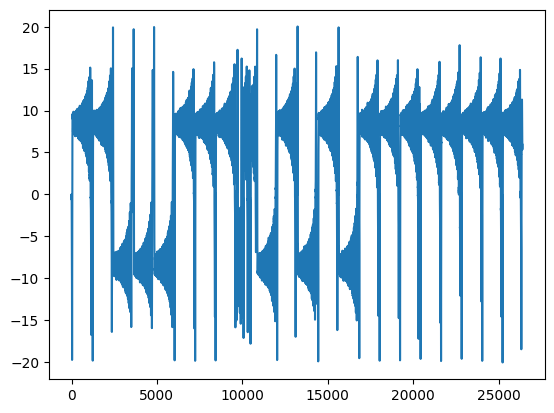

In [71]:
plt.plot(train_flat[:, 0].cpu())

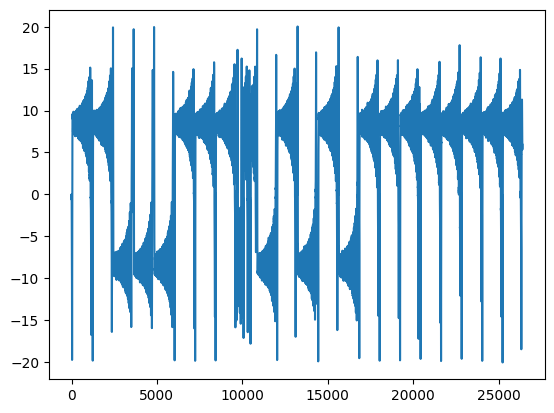

In [72]:
plt.plot(train_flat[:, 0].cpu())

In [41]:
# Assuming train_seq has shape (N_sequences, T_timesteps, D_obs)
# Let's get pairs of consecutive points to find the difference dz
train_seq_dev = train_seq.to(device)

x_t = train_seq_dev[:, :-1, :].reshape(-1, n_obs)
x_next = train_seq_dev[:, 1:, :].reshape(-1, n_obs)

# Sample a batch to avoid memory blowouts
N_diff = min(2000, x_t.shape[0])
x_t = x_t[:N_diff]
x_next = x_next[:N_diff]

with torch.no_grad():
    # Encode both to get z_t and z_{t+1}
    z_t = torch.stack([encode_point(x) for x in x_t])
    z_next = torch.stack([encode_point(x) for x in x_next])
    
    # This is a discrete approximation of a tangent vector!
    dz = z_next - z_t

    # Compute Jacobians ONLY at the starting points x_t
    jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
    U, S, V = torch.linalg.svd(jacobians_t, full_matrices=True)

# Project the difference vector dz onto the local basis U at z_t
# dz is (N, 6). U is (N, 6, 6).
tangent_projection = (dz.unsqueeze(1) @ U).squeeze(1)

print("Mean absolute projection of dz:")
print(tangent_projection.abs().mean(axis=0))

Mean absolute projection of dz:
tensor([3.2827, 1.1067, 1.2231, 0.0089, 0.0110, 0.0087], device='cuda:0')


In [42]:
# Assuming `tangent_projection` is your (N, 6) tensor from the previous step

with torch.no_grad():
    # 1. Square the projections to get the variance/energy per point
    squared_projections = tangent_projection ** 2
    
    # 2. Compute the mean variance across all points for each dimension
    variance_per_dim = squared_projections.mean(dim=0)
    
    # 3. Calculate the total variance
    total_variance = variance_per_dim.sum()
    
    # 4. Get the fractional variance explained
    variance_explained = variance_per_dim / total_variance
    
    # 5. Get the cumulative variance explained
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

# Print the results in a clean table
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |           77.6271% |    77.6271%
Dim 2     |            8.6817% |    86.3088%
Dim 3     |           13.6773% |    99.9861%
Dim 4     |            0.0036% |    99.9897%
Dim 5     |            0.0052% |    99.9949%
Dim 6     |            0.0051% |   100.0000%


## Intrinsic Dimensionality from Variance Partitioning

Principled methods to identify the true tangent-space dimension:
1. **Cumulative variance threshold** — smallest k s.t. Σ λᵢ ≥ threshold (e.g. 95%, 99%)
2. **Broken-stick model** — compare variance to null expectation; keep dims above the break
3. **Elbow (acceleration)** — find k where marginal gain drops sharply

In [43]:
k_max = len(variance_explained)
ve = variance_explained.cpu().numpy()
cv = cumulative_variance.cpu().numpy()

# ---------------------------------------------------------------------------
# 1. Cumulative variance threshold (95%, 99%)
# ---------------------------------------------------------------------------
for thresh in [0.95, 0.99]:
    k_thresh = int(np.searchsorted(cv, thresh)) + 1
    k_thresh = min(k_thresh, k_max)
    print(f"Cumulative variance ≥ {thresh:.0%}: k = {k_thresh}  (cumulative = {cv[k_thresh-1]:.4f})")

# ---------------------------------------------------------------------------
# 2. Broken-stick model (Jackson 1993)
# Under random null: E[λᵢ] = (1/k) Σ_{j=i}^k (1/j). Dimensions with observed
# variance above this expectation are "significant."
# ---------------------------------------------------------------------------
broken_stick = np.array([sum(1/j for j in range(i, k_max + 1)) / k_max for i in range(1, k_max + 1)])
above_stick = ve >= broken_stick
k_broken = int(np.sum(above_stick))  # dims with variance ≥ null expectation
print(f"\nBroken-stick: k = {k_broken}  (dims above null expectation)")

print(f"\n  Per-dimension (obs vs broken-stick):")
for i in range(k_max):
    tag = "✓" if above_stick[i] else " "
    print(f"    Dim {i+1}: {ve[i]*100:6.2f}%  vs  {broken_stick[i]*100:6.2f}%  {tag}")

# ---------------------------------------------------------------------------
# 3. Elbow via maximum curvature (acceleration of cumulative variance)
# ---------------------------------------------------------------------------
# Second derivative of cumulative variance w.r.t. dimension index
accel = np.diff(np.diff(cv))
k_elbow = np.argmin(accel) + 2  # +2: accel[i] corresponds to dim i+2
print(f"\nElbow (min acceleration): k = {k_elbow}")

# ---------------------------------------------------------------------------
# Consensus recommendation
# ---------------------------------------------------------------------------
k_99 = min(np.searchsorted(cv, 0.99) + 1, k_max)
k_rec = k_99  # 99% cumulative variance is the standard choice
print(f"\n→ Recommended intrinsic dimension: k = {k_rec}")

Cumulative variance ≥ 95%: k = 3  (cumulative = 0.9999)
Cumulative variance ≥ 99%: k = 3  (cumulative = 0.9999)

Broken-stick: k = 1  (dims above null expectation)

  Per-dimension (obs vs broken-stick):
    Dim 1:  77.63%  vs   40.83%  ✓
    Dim 2:   8.68%  vs   24.17%   
    Dim 3:  13.68%  vs   15.83%   
    Dim 4:   0.00%  vs   10.28%   
    Dim 5:   0.01%  vs    6.11%   
    Dim 6:   0.01%  vs    2.78%   

Elbow (min acceleration): k = 3

→ Recommended intrinsic dimension: k = 3


## True Jacobian: Tangent/Normal Decomposition & Path Integrals

Using the **true ODE Jacobian** projected into latent space:
1. Decompose into tangent/normal blocks (J_tt, J_tn, J_nt, J_nn) via encoder-Jacobian SVD basis
2. **Two path integrals** (juxtaposed):
   - **A**: Full path integral → project the *result* onto tangent space
   - **B**: Project the *path* onto tangent space → integrate along projected path

In [44]:
from JacobianODE.jacobians.lightning_base import loop_closure as _loop_closure
from JacobianODE.jacobians.jacobianODE import JacobianODE

# Tangent dimension from encoder Jacobian rank
r = min(N_LATENT, n_obs)
N_jac_sample = min(2000, n_points)
jac_idx = torch.randperm(n_points, device=device)[:N_jac_sample]

enc_jacs_sample = encoder_jacs[jac_idx]  # (N_jac, n_latent, n_obs)
U_enc, S_enc, _ = torch.linalg.svd(enc_jacs_sample, full_matrices=True)
# U_enc: (N_jac, n_latent, n_latent)

# Consensus tangent basis
U_tan = U_enc[:, :, :r]
P_tan_avg = (U_tan @ U_tan.transpose(-2, -1)).mean(0)
eigvals, eigvecs = torch.linalg.eigh(P_tan_avg)
eigvals, eigvecs = eigvals.flip(0), eigvecs.flip(1)
V_tan = eigvecs[:, :r]      # (n_latent, r)
V_nrm = eigvecs[:, r:]      # (n_latent, n_latent - r)

# 1. True Jacobian block decomposition (at sampled points)
true_J_sample = true_J_latent[jac_idx]  # (N_jac, n_latent, n_latent)
J_loc = U_enc.transpose(-2, -1) @ true_J_sample @ U_enc

J_tt = J_loc[:, :r, :r]
J_tn = J_loc[:, :r, r:]
J_nt = J_loc[:, r:, :r]
J_nn = J_loc[:, r:, r:]

block_names = ['tan→tan', 'norm→tan', 'tan→norm', 'norm→norm']
blocks = [J_tt, J_tn, J_nt, J_nn]
print("True Jacobian blocks (encoder-Jacobian basis):")
for name, blk in zip(block_names, blocks):
    fn = torch.linalg.norm(blk, dim=(-2, -1), ord='fro')
    print(f"  {name}: mean={fn.mean().item():.4f}, std={fn.std().item():.4f}")

True Jacobian blocks (encoder-Jacobian basis):
  tan→tan: mean=30.1918, std=6.4432
  norm→tan: mean=0.0000, std=0.0000
  tan→norm: mean=0.8917, std=1.2325
  norm→norm: mean=0.0000, std=0.0000


In [45]:
# Estimated Jacobian blocks (same decomposition as true, but from latent Jacobian model)
# Requires lit_model from LOAD_FROM_JACOBIAN_RUN = True
if LOAD_FROM_JACOBIAN_RUN and lit_model is not None:
    lit_model.to(device)
    lit_model.eval()
    z_sample = encoded_points[jac_idx].to(device)  # (N_jac, n_latent)
    with torch.no_grad():
        est_J_sample = lit_model.compute_jacobians(z_sample)  # (N_jac, n_latent, n_latent)

    # Same block decomposition: J_loc = U_enc^T @ J @ U_enc
    J_loc_est = U_enc.transpose(-2, -1) @ est_J_sample @ U_enc

    J_tt_est = J_loc_est[:, :r, :r]
    J_tn_est = J_loc_est[:, :r, r:]
    J_nt_est = J_loc_est[:, r:, :r]
    J_nn_est = J_loc_est[:, r:, r:]

    block_names = ['tan→tan', 'norm→tan', 'tan→norm', 'norm→norm']
    blocks_est = [J_tt_est, J_tn_est, J_nt_est, J_nn_est]
    print("Estimated Jacobian blocks (encoder-Jacobian basis, from latent Jacobian model):")
    for name, blk in zip(block_names, blocks_est):
        fn = torch.linalg.norm(blk, dim=(-2, -1), ord='fro')
        print(f"  {name}: mean={fn.mean().item():.4f}, std={fn.std().item():.4f}")
else:
    print("Skipped: lit_model not available (requires LOAD_FROM_JACOBIAN_RUN=True)")

Estimated Jacobian blocks (encoder-Jacobian basis, from latent Jacobian model):
  tan→tan: mean=28.1988, std=5.8144
  norm→tan: mean=9.9606, std=2.8028
  tan→norm: mean=1.0021, std=0.4791
  norm→norm: mean=3.5985, std=0.7435


## Path Integration with True Jacobians

**Goal**: Confirm that the true Jacobian (projected into latent space) can recover the true latent trajectory when integrated using the same approach as JacobianODE.

We test three approaches:
1. **Direct Euler with true velocities** — Sanity check: compute v_latent = J_enc @ f_obs and Euler-step.
2. **Jacobian velocity propagation (oracle)** — Use true Jacobians at true trajectory points to propagate velocity, matching JacobianODE's fast_mode approach.
3. **JacobianODEint with true Jacobians** — Feed the true Jacobian as `jac_func` into the actual JacobianODEint machinery.

In [46]:
# ── Reshape flat data back to trajectory form ──
n_traj, T_len = train_seq.shape[0], train_seq.shape[1]
print(f"Trajectories: {n_traj}, Length: {T_len}, n_latent: {N_LATENT}, n_obs: {n_obs}")

# Encoded latent trajectories: (n_traj, T, n_latent)
z_trajs = encoded_points.reshape(n_traj, T_len, N_LATENT)

# True Jacobians in latent space: (n_traj, T, n_latent, n_latent)
J_trajs = true_J_latent.reshape(n_traj, T_len, N_LATENT, N_LATENT)

# Encoder Jacobians: (n_traj, T, n_latent, n_obs)
Jenc_trajs = encoder_jacs.reshape(n_traj, T_len, N_LATENT, n_obs)

# ── Compute true latent velocities ──
# v_latent(t) = J_enc(x_t) @ f_norm(x_t)
# where f_norm = (1/σ) * f_raw(x_raw) for scalar σ

x_trajs_raw = train_seq.numpy() * sigma_arr + mu_arr  # (n_traj, T, n_obs) in raw space

v_latent_all = []
for i in range(n_traj):
    # True RHS in raw space: (T, n_obs)
    f_raw = eq.rhs(x_trajs_raw[i], 0)  # autonomous system
    # Convert to normalized space
    f_norm = torch.tensor(f_raw / sigma_arr, dtype=torch.float32, device=device)  # (T, n_obs)
    # Project to latent: v = J_enc @ f_norm
    J_enc_i = Jenc_trajs[i]  # (T, n_latent, n_obs)
    v_lat = (J_enc_i @ f_norm.unsqueeze(-1)).squeeze(-1)  # (T, n_latent)
    v_latent_all.append(v_lat)

v_latent_trajs = torch.stack(v_latent_all)  # (n_traj, T, n_latent)
print(f"True latent velocities shape: {v_latent_trajs.shape}")
print(f"Mean |v|: {v_latent_trajs.norm(dim=-1).mean():.4f}")

# Physical time step
print(f"dt (physical): {dt:.6f}")

Trajectories: 22, Length: 1200, n_latent: 6, n_obs: 3
True latent velocities shape: torch.Size([22, 1200, 6])
Mean |v|: 281.7783
dt (physical): 0.015021


### Test 1: Direct Euler Integration with True Velocities

Sanity check — if we know the true velocity dz/dt at every point, simple Euler integration should recover the trajectory (with small error proportional to dt²).

In [15]:
# ── Test 1: Euler integration with true velocities ──
# z_hat_{t+1} = z_hat_t + dt * v_true(x_t)
# Two variants:
#   (a) Oracle: use true velocity at TRUE x_t (no drift)
#   (b) Free-running: use true velocity at DECODED z_hat_t (allows drift)

# Variant (a): Oracle Euler — velocity always from true trajectory
z_euler_oracle = torch.zeros_like(z_trajs)
z_euler_oracle[:, 0, :] = z_trajs[:, 0, :]

for t_idx in range(T_len - 1):
    z_euler_oracle[:, t_idx + 1, :] = z_euler_oracle[:, t_idx, :] + dt * v_latent_trajs[:, t_idx, :]

# Compute errors
euler_err = (z_euler_oracle - z_trajs).norm(dim=-1)  # (n_traj, T)
print("=== Test 1: Euler with True Velocities (Oracle) ===")
print(f"Mean error at T=100:  {euler_err[:, 100].mean():.6f}")
print(f"Mean error at T=500:  {euler_err[:, 500].mean():.6f}")
print(f"Mean error at T=1000: {euler_err[:, 1000].mean():.6f}")
print(f"Max error (any t):    {euler_err.max():.6f}")

# R² over all trajectories
z_flat_true = z_trajs[:, 1:, :].reshape(-1, N_LATENT)
z_flat_pred = z_euler_oracle[:, 1:, :].reshape(-1, N_LATENT)
ss_res = ((z_flat_true - z_flat_pred) ** 2).sum()
ss_tot = ((z_flat_true - z_flat_true.mean(0)) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"R² (latent space):    {r2:.6f}")

=== Test 1: Euler with True Velocities (Oracle) ===
Mean error at T=100:  0.525928
Mean error at T=500:  0.613714
Mean error at T=1000: 0.977697
Max error (any t):    2.647694
R² (latent space):    0.993033


### Test 2: Jacobian Velocity Propagation (JacobianODE Approach)

This matches JacobianODE's fast_mode integration. Given `traj_init_steps` initial points:
1. Estimate initial velocity from the initial segment (finite differences or true velocity)
2. Propagate velocity using the Jacobian: `v_{t+1} = v_t + H(t, t+dt, z_t, z_{t+1})` where H is the line integral of `J @ dz/dt` along the straight line from `z_t` to `z_{t+1}`
3. Predict: `z_{t+1} = z_t + dt * v_t`

We use the **true Jacobian at true trajectory points** (oracle mode) and also test free-running prediction.

In [16]:
# compute_true_jacobian_at_point and true_jac_func_for_ode are now defined
# in the "Piecewise-Linear H" cell below (with vmap batching for GPU speed).
# This cell just defines the propagation helpers that use precomputed J_trajs.

def H_line_true(z_s, z_t, J_at_z_s, J_at_z_t, s_time, t_time):
    """Compute H integral along a straight line from z_s to z_t using trapezoid rule.
    
    H(s,t) = ∫_s^t J(c(τ)) @ c'(τ) dτ
    For line: c'(τ) = (z_t - z_s) / (t - s), constant.
    Trapezoid: H ≈ (t-s)/2 * [J(z_s) @ c' + J(z_t) @ c']
             = 1/2 * [J(z_s) + J(z_t)] @ (z_t - z_s)
    """
    dz = z_t - z_s
    return 0.5 * (J_at_z_s + J_at_z_t) @ dz


def jacobian_propagate_trajectory(
    z_true,        # (T, n_latent) — true encoded trajectory
    J_true,        # (T, n_latent, n_latent) — true Jacobians at each point
    v_true,        # (T, n_latent) — true latent velocities
    dt_phys,       # physical time step
    traj_init_steps=2,
    free_running=False,
    recompute_jacobians=False,
):
    """Jacobian-based velocity propagation matching JacobianODE fast_mode."""
    T = z_true.shape[0]
    z_pred = torch.zeros_like(z_true)
    v_pred = torch.zeros_like(z_true)
    
    z_pred[:traj_init_steps] = z_true[:traj_init_steps]
    v_pred[:traj_init_steps] = v_true[:traj_init_steps]
    
    base_idx = traj_init_steps - 1
    z_base = z_true[base_idx]
    v_current = v_true[base_idx].clone()
    
    for t_idx in range(base_idx, T - 1):
        z_curr = z_pred[t_idx] if free_running else z_true[t_idx]
        z_next_pred = z_curr + dt_phys * v_current
        z_pred[t_idx + 1] = z_next_pred
        
        if free_running and recompute_jacobians:
            J_curr = compute_true_jacobian_at_point(z_curr)
            J_next = compute_true_jacobian_at_point(z_next_pred)
        else:
            J_curr = J_true[t_idx]
            J_next = J_true[min(t_idx + 1, T - 1)]
        
        if free_running:
            dz = z_next_pred - z_curr
        else:
            dz = z_true[t_idx + 1] - z_true[t_idx]
        
        H_val = 0.5 * (J_curr + J_next) @ dz
        v_current = v_current + H_val
        v_pred[t_idx + 1] = v_current
    
    return z_pred, v_pred


print("Helper functions defined.")

Helper functions defined.


In [17]:
# # ── Test 2a: Oracle Jacobian propagation (true J at true points) ──
# # This is the cleanest test: can the first-order Jacobian expansion
# # propagate velocity accurately along the true trajectory?

# def run_oracle_jacobian_propagation(traj_init_steps=50, start_idx=0):
#     """
#     Runs the oracle Jacobian propagation beginning at a custom start index in the trajectory.

#     Args:
#         traj_init_steps (int): Number of initial steps to provide to the propagator.
#         start_idx (int): Index in the trajectory at which to start the propagation.
#     """
#     results_oracle = []

#     for i_traj in range(n_traj):
#         # Restrict to sub-trajectory if requested
#         z_true = z_trajs[i_traj][start_idx:]
#         J_true = J_trajs[i_traj][start_idx:]
#         v_true = v_latent_trajs[i_traj][start_idx:]

#         z_pred, v_pred = jacobian_propagate_trajectory(
#             z_true, J_true, v_true,
#             dt_phys=dt, traj_init_steps=traj_init_steps, free_running=False,
#         )
#         err = (z_pred - z_true).norm(dim=-1)
#         results_oracle.append({
#             'z_pred': z_pred, 'v_pred': v_pred, 'err': err,
#         })

#     errs_oracle = torch.stack([r['err'] for r in results_oracle])  # (n_traj, T)
#     print(f"=== Test 2a: Oracle Jacobian Propagation (traj_init={traj_init_steps}, start_idx={start_idx}) ===")
#     idx100 = 100 if errs_oracle.shape[1] > 100 else errs_oracle.shape[1] - 1
#     idx500 = 500 if errs_oracle.shape[1] > 500 else errs_oracle.shape[1] - 1
#     idx1000 = 1000 if errs_oracle.shape[1] > 1000 else errs_oracle.shape[1] - 1
#     print(f"Mean error at T=100:  {errs_oracle[:, idx100].mean():.6f}")
#     print(f"Mean error at T=500:  {errs_oracle[:, idx500].mean():.6f}")
#     print(f"Mean error at T=1000: {errs_oracle[:, idx1000].mean():.6f}")
#     print(f"Max error (any t):    {errs_oracle.max():.6f}")

#     # R²
#     z_pred_all = torch.stack([r['z_pred'] for r in results_oracle])
#     z_p = z_pred_all[:, traj_init_steps:].reshape(-1, N_LATENT)
#     z_t = z_trajs[:, start_idx+traj_init_steps:].reshape(-1, N_LATENT)
#     ss_res = ((z_t - z_p) ** 2).sum()
#     ss_tot = ((z_t - z_t.mean(0)) ** 2).sum()
#     print(f"R² (latent space):    {(1 - ss_res / ss_tot):.6f}")
#     return results_oracle, z_trajs[:, start_idx:], z_pred_all

# # Example usage:
# TRAJ_INIT_STEPS = 15
# START_IDX = 200  # Change this to start at a different index
# results_oracle, z_trajs_crop, z_pred_all_crop = run_oracle_jacobian_propagation(traj_init_steps=TRAJ_INIT_STEPS, start_idx=START_IDX)

# plt.plot(z_trajs_crop[0, :, 0].cpu())
# plt.plot(z_pred_all_crop[0, :, 0].cpu())
# plt.show()


In [18]:
# # ── Test 2a (alt): Oracle Jacobian propagation via JacobianODEint.generate_dynamics ──
# # Uses the repo's full integration machinery (RK4 + spline/line paths)
# # instead of the manual Euler + trapezoid approach.

# from JacobianODE.jacobians.jacobianODE import JacobianODEint

# INTERP_PTS = 20  # large number of interpolation points

# def run_oracle_jacobian_propagation(traj_init_steps=50, start_idx=0):
#     """
#     Runs oracle Jacobian propagation using JacobianODEint.generate_dynamics.

#     Args:
#         traj_init_steps (int): Number of initial steps to provide.
#         start_idx (int): Index in the trajectory at which to start.
#     """
#     jacobian_odeint = JacobianODEint(true_jac_func_for_ode, dt)
#     results_oracle = []

#     # for i_traj in tqdm(range(n_traj), desc="Trajectories"):
#     for i_traj in tqdm(range(1)):
#         z_true = z_trajs[i_traj][start_idx:]  # (T', n_latent)

#         z_pred = jacobian_odeint.generate_dynamics(
#             z_true.unsqueeze(0),               # (1, T', n_latent)
#             traj_init_steps=traj_init_steps,
#             fast_mode=True,
#             inner_path="line",
#             inner_N=INTERP_PTS,
#             scale_interp_pts=True,
#             interp_pts=4,
#             alpha_teacher_forcing=1,
#             # alpha_teacher_forcing=0.3,
#             odeint_kwargs={"method": "rk4"},
#         ).squeeze(0)  # (T', n_latent)

#         err = (z_pred - z_true).norm(dim=-1)
#         results_oracle.append({
#             'z_pred': z_pred, 'v_pred': None, 'err': err,
#         })

#     errs_oracle = torch.stack([r['err'] for r in results_oracle])  # (n_traj, T')
#     print(f"=== Test 2a: JacobianODEint Propagation (traj_init={traj_init_steps}, start_idx={start_idx}, interp_pts={INTERP_PTS}) ===")
#     idx100 = 100 if errs_oracle.shape[1] > 100 else errs_oracle.shape[1] - 1
#     idx500 = 500 if errs_oracle.shape[1] > 500 else errs_oracle.shape[1] - 1
#     idx1000 = 1000 if errs_oracle.shape[1] > 1000 else errs_oracle.shape[1] - 1
#     print(f"Mean error at T=100:  {errs_oracle[:, idx100].mean():.6f}")
#     print(f"Mean error at T=500:  {errs_oracle[:, idx500].mean():.6f}")
#     print(f"Mean error at T=1000: {errs_oracle[:, idx1000].mean():.6f}")
#     print(f"Max error (any t):    {errs_oracle.max():.6f}")

#     # R²
#     z_pred_all = torch.stack([r['z_pred'] for r in results_oracle])
#     z_p = z_pred_all[:, traj_init_steps:].reshape(-1, N_LATENT)
#     z_t = z_trajs[:z_pred_all.shape[0], start_idx+traj_init_steps:].reshape(-1, N_LATENT)
#     ss_res = ((z_t - z_p) ** 2).sum()
#     ss_tot = ((z_t - z_t.mean(0)) ** 2).sum()
#     print(f"R² (latent space):    {(1 - ss_res / ss_tot):.6f}")
#     return results_oracle, z_trajs[:, start_idx:], z_pred_all

# # Example usage:
# TRAJ_INIT_STEPS = 15
# START_IDX = 200
# results_oracle, z_trajs_crop, z_pred_all_crop = run_oracle_jacobian_propagation(traj_init_steps=TRAJ_INIT_STEPS, start_idx=START_IDX)

# plt.plot(z_trajs_crop[0, :, 0].cpu())
# plt.plot(z_pred_all_crop[0, :, 0].detach().cpu())
# plt.show()

In [19]:
# # ── Test 2a (alt) with PREDICTED Jacobians ──
# # Same as oracle propagation, but uses the latent Jacobian model's predicted Jacobians.
# # Requires lit_model from LOAD_FROM_JACOBIAN_RUN = True

# if LOAD_FROM_JACOBIAN_RUN and lit_model is not None:
#     lit_model.to(device)
#     lit_model.eval()

#     def pred_jac_func_for_ode(z, t):
#         """Compute predicted Jacobians from the latent Jacobian model at latent point(s) z."""
#         with torch.no_grad():
#             return lit_model.compute_jacobians(z)

#     from JacobianODE.jacobians.jacobianODE import JacobianODEint

#     def run_predicted_jacobian_propagation(traj_init_steps=50, start_idx=0):
#         """Same as run_oracle_jacobian_propagation but uses predicted Jacobians."""
#         jacobian_odeint = JacobianODEint(pred_jac_func_for_ode, dt)
#         results = []

#         for i_traj in tqdm(range(1)):
#             z_true = z_trajs[i_traj][start_idx:]  # (T', n_latent)

#             z_pred = jacobian_odeint.generate_dynamics(
#                 z_true.unsqueeze(0),
#                 traj_init_steps=traj_init_steps,
#                 fast_mode=True,
#                 inner_path="line",
#                 inner_N=INTERP_PTS,
#                 scale_interp_pts=True,
#                 interp_pts=INTERP_PTS,
#                 # alpha_teacher_forcing=1,
#                 alpha_teacher_forcing=0.3,
#                 odeint_kwargs={"method": "rk4"},
#             ).squeeze(0)

#             err = (z_pred - z_true).norm(dim=-1)
#             results.append({'z_pred': z_pred, 'v_pred': None, 'err': err})

#         errs = torch.stack([r['err'] for r in results])
#         print(f"=== Predicted Jacobian: JacobianODEint Propagation (traj_init={traj_init_steps}, start_idx={start_idx}, interp_pts={INTERP_PTS}) ===")
#         idx100 = 100 if errs.shape[1] > 100 else errs.shape[1] - 1
#         idx500 = 500 if errs.shape[1] > 500 else errs.shape[1] - 1
#         idx1000 = 1000 if errs.shape[1] > 1000 else errs.shape[1] - 1
#         print(f"Mean error at T=100:  {errs[:, idx100].mean():.6f}")
#         print(f"Mean error at T=500:  {errs[:, idx500].mean():.6f}")
#         print(f"Mean error at T=1000: {errs[:, idx1000].mean():.6f}")
#         print(f"Max error (any t):    {errs.max():.6f}")

#         z_pred_all = torch.stack([r['z_pred'] for r in results])
#         z_p = z_pred_all[:, traj_init_steps:].reshape(-1, N_LATENT)
#         z_t = z_trajs[:z_pred_all.shape[0], start_idx+traj_init_steps:].reshape(-1, N_LATENT)
#         ss_res = ((z_t - z_p) ** 2).sum()
#         ss_tot = ((z_t - z_t.mean(0)) ** 2).sum()
#         print(f"R² (latent space):    {(1 - ss_res / ss_tot):.6f}")
#         return results, z_trajs[:, start_idx:], z_pred_all

#     results_pred, z_trajs_crop_pred, z_pred_all_crop_pred = run_predicted_jacobian_propagation(
#         traj_init_steps=TRAJ_INIT_STEPS, start_idx=START_IDX
#     )

#     plt.plot(z_trajs_crop_pred[0, :, 0].cpu())
#     plt.plot(z_pred_all_crop_pred[0, :, 0].detach().cpu())
#     plt.show()
# else:
#     print("Skipped: lit_model not available (requires LOAD_FROM_JACOBIAN_RUN=True)")

## Loop Closure with True Jacobian

Test whether the true Jacobian (projected into latent space) satisfies path independence.
Pick random points from the encoded training set, form closed loops (concatenation of
line segments returning to the start point), and integrate the Jacobian along each loop.
If the latent Jacobian field is conservative, the integral around every closed loop should be **zero**.

In [20]:
# ── Define true_jac_func_for_ode: computes true latent Jacobian at any z ──
# Interface: jac_func(z, t) -> J_latent  (works for batched z)

# ── Sanity check ──
# The precomputed true_J_latent evaluates J_enc and eq.jac at the ORIGINAL x,
# while true_jac_func_for_ode(z) decodes z -> x_recon and evaluates there.
# Since decoder(encoder(x)) != x, they differ. Let's quantify both:
with torch.no_grad():
    test_z = encoded_points[:5]
    test_x = train_flat[:5]
    J_func = true_jac_func_for_ode(test_z, 0)
    J_precomp = true_J_latent[:5]
    
    # Reconstruction error drives the Jacobian difference
    x_recon = adapter.decoder(test_z)
    recon_err = (x_recon - test_x).norm(dim=-1)
    
    print("Sanity check — func vs precomputed (expected to differ due to AE recon error):")
    print(f"  Max Jacobian diff:     {(J_func - J_precomp).abs().max().item():.4f}")
    print(f"  Mean Jacobian diff:    {(J_func - J_precomp).abs().mean().item():.4f}")
    print(f"  Mean recon error ||decoder(encoder(x)) - x||: {recon_err.mean().item():.4f}")
    print(f"  Mean ||J_precomp||:    {J_precomp.norm(dim=(-2,-1)).mean().item():.4f}")
    print(f"  Relative Jacobian diff: {(J_func - J_precomp).norm(dim=(-2,-1)).mean().item() / J_precomp.norm(dim=(-2,-1)).mean().item():.4f}")

Sanity check — func vs precomputed (expected to differ due to AE recon error):
  Max Jacobian diff:     1.2337
  Mean Jacobian diff:    0.3171
  Mean recon error ||decoder(encoder(x)) - x||: 0.0220
  Mean ||J_precomp||:    72.2271
  Relative Jacobian diff: 0.0326


In [21]:
# ── Loop Closure Loss with True Jacobian ──
# Same as LitLatentJacobianODE / loop_closure_model_step: uses loop_closure() from
# the training pipeline with true Jacobian. interpolation_points=20 for high accuracy
# (matching Test 2a JacobianODEint).

from JacobianODE.jacobians.lightning_base import loop_closure, make_loops

# Use encoded training points as the pool of points to sample loops from
# Reshape to (n_traj, T, n_latent) so loop_closure can sample from them
z_batch = z_trajs.detach()  # (n_traj, T, n_latent)

# Settings matching the training pipeline
N_LOOPS = 20        # number of closed loops
N_LOOP_PTS = 5       # waypoints per loop (before closing)
INTERP_PTS = 20      # interpolation points per segment (high accuracy, same as Test 2a)
LOOP_PATH = 'line'

loop_int = loop_closure(
    z_batch,
    jac_func=true_jac_func_for_ode,
    dt=dt,
    n_loops=N_LOOPS,
    n_loop_pts=N_LOOP_PTS,
    loop_path=LOOP_PATH,
    loop_closure_interp_pts=INTERP_PTS,
    # mix_trajectories=True,
    mix_trajectories=True,
    alpha=1,
)

# loop_int shape: (N_LOOPS, n_latent) — the integral around each closed loop
loop_norms = torch.linalg.norm(loop_int, dim=-1)

# Loop closure loss (same as LitBase.loop_closure_model_step: (loop_int**2).mean())
loop_closure_loss = (loop_int**2).mean()

print(f"=== Loop Closure with True Jacobian (interp_pts={INTERP_PTS}) ===")
print(f"Loops: {N_LOOPS}, waypoints/loop: {N_LOOP_PTS}, interp pts: {INTERP_PTS}")
print(f"Loop integral norms:")
print(f"  Mean:   {loop_norms.mean().item():.6f}")
print(f"  Std:    {loop_norms.std().item():.6f}")
print(f"  Median: {loop_norms.median().item():.6f}")
print(f"  Max:    {loop_norms.max().item():.6f}")
print(f"  Min:    {loop_norms.min().item():.6f}")
print(f"\nLoop closure loss (loop_int² mean): {loop_closure_loss.item():.6f}")

# Per-dimension breakdown
print(f"\nPer-dimension loop integral stats:")
for d in range(N_LATENT):
    vals = loop_int[:, d]
    print(f"  z[{d}]: mean={vals.mean().item():.6f}, std={vals.std().item():.6f}, "
          f"|mean|={vals.abs().mean().item():.6f}")

=== Loop Closure with True Jacobian (interp_pts=20) ===
Loops: 20, waypoints/loop: 5, interp pts: 20
Loop integral norms:
  Mean:   10.562911
  Std:    11.216897
  Median: 6.855711
  Max:    45.746578
  Min:    0.619248

Loop closure loss (loop_int² mean): 38.517159

Per-dimension loop integral stats:
  z[0]: mean=-3.707747, std=8.447237, |mean|=5.197997
  z[1]: mean=3.084171, std=7.967881, |mean|=5.368920
  z[2]: mean=0.607425, std=5.620742, |mean|=3.945649
  z[3]: mean=1.284009, std=3.643967, |mean|=2.177632
  z[4]: mean=-1.386518, std=4.972994, |mean|=2.462143
  z[5]: mean=-0.779750, std=3.090345, |mean|=2.395976


In [22]:
# ── Loop Closure Loss with Predicted Jacobian ──
# Same as above, but uses predicted Jacobians from the latent Jacobian ODE model.
# Requires LOAD_FROM_JACOBIAN_RUN=True and lit_model.

def pred_jac_func_for_ode(z, t):
    """Compute predicted Jacobians from the latent Jacobian model at latent point(s) z."""
    with torch.no_grad():
        return lit_model.compute_jacobians(z)

lit_model.to(device)
lit_model.eval()

loop_int_pred = loop_closure(
    z_batch,
    jac_func=pred_jac_func_for_ode,
    dt=dt,
    n_loops=N_LOOPS,
    n_loop_pts=N_LOOP_PTS,
    loop_path=LOOP_PATH,
    loop_closure_interp_pts=INTERP_PTS,
    mix_trajectories=True,
    alpha=1,
)

loop_norms_pred = torch.linalg.norm(loop_int_pred, dim=-1)
loop_closure_loss_pred = (loop_int_pred**2).mean()

print(f"=== Loop Closure with Predicted Jacobian (interp_pts={INTERP_PTS}) ===")
print(f"Loops: {N_LOOPS}, waypoints/loop: {N_LOOP_PTS}, interp pts: {INTERP_PTS}")
print(f"Loop integral norms:")
print(f"  Mean:   {loop_norms_pred.mean().item():.6f}")
print(f"  Std:    {loop_norms_pred.std().item():.6f}")
print(f"  Median: {loop_norms_pred.median().item():.6f}")
print(f"  Max:    {loop_norms_pred.max().item():.6f}")
print(f"  Min:    {loop_norms_pred.min().item():.6f}")
print(f"\nLoop closure loss (loop_int² mean): {loop_closure_loss_pred.item():.6f}")

# Per-dimension breakdown
print(f"\nPer-dimension loop integral stats:")
for d in range(N_LATENT):
    vals = loop_int_pred[:, d]
    print(f"  z[{d}]: mean={vals.mean().item():.6f}, std={vals.std().item():.6f}, "
          f"|mean|={vals.abs().mean().item():.6f}")

=== Loop Closure with Predicted Jacobian (interp_pts=20) ===
Loops: 20, waypoints/loop: 5, interp pts: 20
Loop integral norms:
  Mean:   9.042644
  Std:    10.037847
  Median: 5.273298
  Max:    38.596478
  Min:    0.862794

Loop closure loss (loop_int² mean): 29.581642

Per-dimension loop integral stats:
  z[0]: mean=0.274557, std=3.268385, |mean|=2.487074
  z[1]: mean=0.126689, std=1.933617, |mean|=1.348032
  z[2]: mean=-0.245107, std=1.800559, |mean|=1.252267
  z[3]: mean=3.596800, std=10.143435, |mean|=6.377103
  z[4]: mean=-1.349496, std=5.869451, |mean|=3.168517
  z[5]: mean=1.060151, std=3.866661, |mean|=1.849267


In [23]:
# # ── Visualize loop closure results ──

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# # 1. Histogram of loop integral norms
# ax = axes[0]
# ax.hist(loop_norms.detach().cpu().numpy(), bins=30, edgecolor='black', alpha=0.7)
# ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero (ideal)')
# ax.set_xlabel('||Loop Integral||')
# ax.set_ylabel('Count')
# ax.set_title('Loop Closure Integral Norms')
# ax.legend()

# # 2. Per-dimension histograms
# ax = axes[1]
# for d in range(N_LATENT):
#     ax.hist(loop_int[:, d].detach().cpu().numpy(), bins=30, alpha=0.5, label=f'z[{d}]')
# ax.axvline(0, color='r', linestyle='--', linewidth=2)
# ax.set_xlabel('Loop Integral Value')
# ax.set_ylabel('Count')
# ax.set_title('Per-Dimension Loop Integrals')
# ax.legend()

# # 3. Show a few example loops in latent space (first 2 dims)
# ax = axes[2]
# # Reconstruct a few loops for visualization
# sample_loops = make_loops(z_batch, n_loops=5, n_loop_pts=N_LOOP_PTS).detach().cpu().numpy()
# for i in range(sample_loops.shape[0]):
#     ax.plot(sample_loops[i, :, 0], sample_loops[i, :, 1], 'o-', alpha=0.7, label=f'Loop {i}')
# ax.set_xlabel('z[0]')
# ax.set_ylabel('z[1]')
# ax.set_title('Example Loops in Latent Space')
# ax.legend(fontsize=7)

# plt.tight_layout()
# plt.show()

# # ── Convergence test: vary interpolation points ──
# print("\n=== Convergence with interpolation points ===")
# for n_interp in [2, 5, 10, 20, 50]:
#     li = loop_closure(
#         z_batch, jac_func=true_jac_func_for_ode, dt=dt,
#         n_loops=50, n_loop_pts=N_LOOP_PTS, loop_path='line',
#         loop_closure_interp_pts=n_interp, mix_trajectories=True, alpha=1,
#     )
#     norms = torch.linalg.norm(li, dim=-1)
#     print(f"  interp_pts={n_interp:3d}: mean_norm={norms.mean().item():.6f}, "
#           f"max_norm={norms.max().item():.6f}")

## Geodesic Loop Closure

The random-line loop closure test above integrates along straight lines that cut through
empty space off the data manifold. The hypothesis: the Jacobian field is only integrable
**on the manifold**, so loops must stay on-manifold.

**Approach**: Build a KNN graph from encoded training points, compute shortest-path
geodesics between waypoints, and integrate along those geodesic paths (chains of short
segments between actual data points). Since we pass through real data points, we use the
**precomputed** `true_J_latent` directly — no decoder reconstruction error.

In [24]:
# ── Cell 1: Build KNN Graph ──
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components

K_NEIGHBORS = 15

enc_np = encoded_points.detach().cpu().numpy()  # (26400, 3)
n_pts = enc_np.shape[0]

# Build KNN
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
nn.fit(enc_np)
distances, indices = nn.kneighbors(enc_np)  # (26400, K)

# Sparse adjacency matrix (symmetric, weighted by Euclidean distance)
rows = np.repeat(np.arange(n_pts), K_NEIGHBORS)
cols = indices.ravel()
weights = distances.ravel()
graph = csr_matrix((weights, (rows, cols)), shape=(n_pts, n_pts))
graph = graph.maximum(graph.T)  # symmetrize

# Check connectivity
n_components, labels = connected_components(graph, directed=False)

print(f"KNN graph: {n_pts} nodes, K={K_NEIGHBORS}")
print(f"Edges (nnz): {graph.nnz}")
print(f"Graph density: {graph.nnz / n_pts**2:.6f}")
print(f"Mean edge weight: {graph.data.mean():.4f}")
print(f"Connected components: {n_components}")
if n_components > 1:
    comp_sizes = np.bincount(labels)
    print(f"  Component sizes: {sorted(comp_sizes, reverse=True)[:10]}")

KNN graph: 26400 nodes, K=15
Edges (nnz): 430114
Graph density: 0.000617
Mean edge weight: 0.2086
Connected components: 1


In [53]:
# ── Cell 2: Geodesic Loop Generation & Integration (using JacobianODE.H) ──

from JacobianODE.jacobians.jacobianODE import JacobianODE

N_CANDIDATES = 500   # pool of candidate waypoints
N_LOOPS = 5        # number of closed loops
N_LOOP_PTS = 4       # waypoints per loop
INTERP_PTS_GEO = 20  # interpolation points per segment (matching random-line test)

# 1. Select candidate waypoints (from largest connected component if fragmented)
if n_components > 1:
    largest_comp = np.argmax(np.bincount(labels))
    valid_indices = np.where(labels == largest_comp)[0]
    candidate_indices = np.random.choice(valid_indices, size=min(N_CANDIDATES, len(valid_indices)), replace=False)
else:
    candidate_indices = np.random.choice(n_pts, size=N_CANDIDATES, replace=False)

# 2. Compute shortest paths from candidates only
print(f"Computing shortest paths from {len(candidate_indices)} candidates...")
dist_matrix, predecessors = shortest_path(
    graph, method='D', directed=False,
    indices=candidate_indices, return_predecessors=True,
)
print(f"  dist_matrix shape: {dist_matrix.shape}")
print(f"  Reachable fraction: {np.isfinite(dist_matrix).mean():.4f}")

# 3. Path reconstruction
def reconstruct_path(src_row, target_idx):
    """Reconstruct shortest path from candidate (by row) to target using predecessors."""
    source_idx = candidate_indices[src_row]
    if source_idx == target_idx:
        return [int(target_idx)]
    path = [int(target_idx)]
    current = int(target_idx)
    for _ in range(n_pts):
        current = int(predecessors[src_row, current])
        if current == -9999:
            return None
        path.append(current)
        if current == source_idx:
            break
    else:
        return None
    path.reverse()
    return path

# 4. Build geodesic loop waypoint tensors and integrate using JacobianODE.H()
def run_geodesic_loop_closure(n_loops, n_loop_pts, interp_pts, jac_func, use_precomputed_J=False):
    """Generate geodesic loops and integrate using the codebase's JacobianODE.H() machinery.
    
    Args:
        use_precomputed_J: If True, use precomputed true_J_latent at data points (trapezoid).
                          If False, use jac_func via JacobianODE.H() with interpolation.
    """
    loop_integrals = []
    loop_lengths = []
    loop_paths_viz = []
    skipped = 0
    
    for loop_i in range(n_loops):
        wp_rows = np.random.choice(len(candidate_indices), size=n_loop_pts, replace=False)
        
        # Build full closed geodesic path
        full_path_indices = []
        valid = True
        for seg in range(n_loop_pts):
            src_row = wp_rows[seg]
            tgt_global = int(candidate_indices[wp_rows[(seg + 1) % n_loop_pts]])
            path = reconstruct_path(src_row, tgt_global)
            if path is None:
                valid = False
                break
            if seg > 0:
                path = path[1:]
            full_path_indices.extend(path)
        
        if not valid:
            skipped += 1
            continue
        
        path_idx = np.array(full_path_indices)
        z_path = encoded_points[path_idx]  # (M, n_latent)
        M = z_path.shape[0]
        
        if use_precomputed_J:
            # Trapezoid with precomputed Jacobians (no decoder error)
            J_path = true_J_latent[path_idx]
            dz = z_path[1:] - z_path[:-1]
            J_avg = 0.5 * (J_path[:-1] + J_path[1:])
            loop_int = (J_avg @ dz.unsqueeze(-1)).squeeze(-1).sum(dim=0)
        else:
            # Use JacobianODE.H() with full interpolation (same as loop_closure())
            # Construct loop_pts tensor: (1, M, n_latent) for JacobianODE
            loop_pts = z_path.unsqueeze(0)  # (1, M, n_latent)
            jacobian_ode = JacobianODE(loop_pts, jac_func, dt=dt, fit_spline=False, int_method='Trapezoid')
            N = interp_pts + 2
            loop_int = torch.zeros(1, z_path.shape[-1], dtype=z_path.dtype, device=z_path.device)
            for _t in range(M - 1):
                s = torch.tensor(_t * dt, dtype=z_path.dtype, device=z_path.device)
                t = torch.tensor((_t + 1) * dt, dtype=z_path.dtype, device=z_path.device)
                x_s = loop_pts[..., _t, :]
                x_t = loop_pts[..., _t + 1, :]
                loop_int += jacobian_ode.H(s, t, x_s, x_t, inner_path="line", N=N)
            loop_int = loop_int.squeeze(0)
        
        loop_integrals.append(loop_int.detach().cpu())
        loop_lengths.append(M)
        if loop_i < 10:
            loop_paths_viz.append(z_path.detach().cpu())
    
    loop_integrals = torch.stack(loop_integrals)
    norms = torch.linalg.norm(loop_integrals, dim=-1)
    return loop_integrals, norms, loop_lengths, loop_paths_viz, skipped

# ── Run with precomputed Jacobians (trapezoid, no decoder error) ──
print("\n--- Precomputed Jacobians (trapezoid, no decoder error) ---")
loop_integrals_geo, geodesic_norms, loop_geo_lengths, loop_paths_for_viz, skipped = \
    run_geodesic_loop_closure(N_LOOPS, N_LOOP_PTS, INTERP_PTS_GEO, 
                               true_jac_func_for_ode, use_precomputed_J=True)

print(f"\n=== Geodesic Loop Closure — Precomputed J (K={K_NEIGHBORS}, {N_LOOP_PTS} waypoints) ===")
print(f"Valid loops: {len(geodesic_norms)} / {N_LOOPS} (skipped {skipped})")
print(f"Mean geodesic length (# points): {np.mean(loop_geo_lengths):.1f}")
print(f"Loop integral norms:")
print(f"  Mean:   {geodesic_norms.mean().item():.6f}")
print(f"  Median: {geodesic_norms.median().item():.6f}")
print(f"  Max:    {geodesic_norms.max().item():.6f}")

# ── Run with JacobianODE.H() and true_jac_func_for_ode (with interpolation) ──
# This is slower (evaluates jac_func at interpolated points), so use fewer loops
print("\n--- JacobianODE.H() with true_jac_func_for_ode (interp_pts=10) ---")
loop_integrals_geo_H, geodesic_norms_H, _, _, skipped_H = \
    run_geodesic_loop_closure(20, N_LOOP_PTS, INTERP_PTS_GEO, 
                               true_jac_func_for_ode, use_precomputed_J=False)

print(f"Valid loops: {len(geodesic_norms_H)} / 20 (skipped {skipped_H})")
print(f"Loop integral norms (JacobianODE.H):")
print(f"  Mean:   {geodesic_norms_H.mean().item():.6f}")
print(f"  Median: {geodesic_norms_H.median().item():.6f}")
print(f"  Max:    {geodesic_norms_H.max().item():.6f}")

# ── Comparison ──
print(f"\n--- Comparison ---")
print(f"Random lines (from earlier):       mean norm = {loop_norms.mean().item():.4f}")
print(f"Geodesic (precomputed J):          mean norm = {geodesic_norms.mean().item():.4f}")
print(f"Geodesic (JacobianODE.H interp):   mean norm = {geodesic_norms_H.mean().item():.4f}")

# ── Convergence test: interpolation points for geodesic loops ──
print("\n=== Convergence with interpolation points (geodesic, precomputed J) ===")
print("(Precomputed J uses trapezoid — interp_pts don't apply, result is constant)")
print("Testing JacobianODE.H with varying interp_pts on 10 geodesic loops:")
for n_interp in [2, 5, 10, 20]:
    _, norms_i, _, _, _ = run_geodesic_loop_closure(
        10, N_LOOP_PTS, n_interp, true_jac_func_for_ode, use_precomputed_J=False)
    print(f"  interp_pts={n_interp:3d}: mean_norm={norms_i.mean().item():.6f}")

Computing shortest paths from 500 candidates...
  dist_matrix shape: (500, 26400)
  Reachable fraction: 1.0000

--- Precomputed Jacobians (trapezoid, no decoder error) ---

=== Geodesic Loop Closure — Precomputed J (K=15, 4 waypoints) ===
Valid loops: 5 / 5 (skipped 0)
Mean geodesic length (# points): 220.8
Loop integral norms:
  Mean:   0.193720
  Median: 0.093265
  Max:    0.682063

--- JacobianODE.H() with true_jac_func_for_ode (interp_pts=10) ---
Valid loops: 20 / 20 (skipped 0)
Loop integral norms (JacobianODE.H):
  Mean:   1.467578
  Median: 0.886918
  Max:    5.000608

--- Comparison ---
Random lines (from earlier):       mean norm = 1.0357
Geodesic (precomputed J):          mean norm = 0.1937
Geodesic (JacobianODE.H interp):   mean norm = 1.4676

=== Convergence with interpolation points (geodesic, precomputed J) ===
(Precomputed J uses trapezoid — interp_pts don't apply, result is constant)
Testing JacobianODE.H with varying interp_pts on 10 geodesic loops:
  interp_pts=  2: m

In [30]:
# # ── Cell 3: Visualization & Comparison ──

# fig = plt.figure(figsize=(18, 10))

# # 1. Histogram comparison: random lines vs geodesic
# ax1 = fig.add_subplot(2, 3, 1)
# ax1.hist(loop_norms.detach().cpu().numpy(), bins=30, alpha=0.6, label='Random lines', color='C1')
# ax1.hist(geodesic_norms.numpy(), bins=30, alpha=0.6, label='Geodesic', color='C0')
# ax1.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero (ideal)')
# ax1.set_xlabel('||Loop Integral||')
# ax1.set_ylabel('Count')
# ax1.set_title('Loop Closure: Random Lines vs Geodesic')
# ax1.legend()

# # 2. Per-dimension histograms (geodesic)
# ax2 = fig.add_subplot(2, 3, 2)
# for d in range(N_LATENT):
#     ax2.hist(loop_integrals_geo[:, d].numpy(), bins=30, alpha=0.5, label=f'z[{d}]')
# ax2.axvline(0, color='r', linestyle='--', linewidth=2)
# ax2.set_xlabel('Loop Integral Value')
# ax2.set_ylabel('Count')
# ax2.set_title('Geodesic: Per-Dimension Integrals')
# ax2.legend()

# # 3. Box plot comparison
# ax3 = fig.add_subplot(2, 3, 3)
# data = [loop_norms.detach().cpu().numpy(), geodesic_norms.numpy()]
# bp = ax3.boxplot(data, labels=['Random\nLines', 'Geodesic'], patch_artist=True)
# bp['boxes'][0].set_facecolor('C1')
# bp['boxes'][0].set_alpha(0.6)
# bp['boxes'][1].set_facecolor('C0')
# bp['boxes'][1].set_alpha(0.6)
# ax3.set_ylabel('||Loop Integral||')
# ax3.set_title('Distribution Comparison')

# # 4. 3D scatter with geodesic loops
# ax4 = fig.add_subplot(2, 3, 4, projection='3d')
# sub = np.random.choice(n_pts, size=2000, replace=False)
# # Fix: ensure correct usage of 's' and no double passing to .scatter.
# points = enc_np[sub]
# ax4.scatter(points[:, 0], points[:, 1], points[:, 2], alpha=0.03, s=1, c='gray')
# for i, path in enumerate(loop_paths_for_viz[:5]):
#     p = path.numpy()
#     ax4.plot(p[:, 0], p[:, 1], p[:, 2], 'o-', markersize=1.5, alpha=0.7, 
#              linewidth=1.5, label=f'Loop {i}')
# ax4.set_xlabel('z[0]')
# ax4.set_ylabel('z[1]')
# ax4.set_zlabel('z[2]')
# ax4.set_title('Geodesic Loops in Latent Space')
# ax4.legend(fontsize=6)

# # 5. Integral norm vs geodesic path length
# ax5 = fig.add_subplot(2, 3, 5)
# ax5.scatter(loop_geo_lengths[:len(geodesic_norms)], geodesic_norms.numpy(), alpha=0.4, s=15)
# ax5.set_xlabel('Geodesic Length (# points)')
# ax5.set_ylabel('||Loop Integral||')
# ax5.set_title('Integral Norm vs Path Length')

# # 6. K sensitivity analysis
# ax6 = fig.add_subplot(2, 3, 6)
# k_values = [5, 10, 15, 20, 30]
# mean_norms_by_k = []
# std_norms_by_k = []
# print("=== K Sensitivity Analysis ===")
# for k in k_values:
#     nn_k = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(enc_np)
#     d_k, i_k = nn_k.kneighbors(enc_np)
#     rows_k = np.repeat(np.arange(n_pts), k)
#     g_k = csr_matrix((d_k.ravel(), (rows_k, i_k.ravel())), shape=(n_pts, n_pts))
#     g_k = g_k.maximum(g_k.T)
    
#     # Use a smaller subset for speed
#     cand_k = candidate_indices[:200]
#     dm_k, pred_k = shortest_path(g_k, method='D', directed=False,
#                                   indices=cand_k, return_predecessors=True)
    
#     norms_k = []
#     for _ in range(50):
#         wp_rows = np.random.choice(len(cand_k), size=N_LOOP_PTS, replace=False)
#         full_path = []
#         ok = True
#         for seg in range(N_LOOP_PTS):
#             src_r = wp_rows[seg]
#             tgt_g = int(cand_k[wp_rows[(seg + 1) % N_LOOP_PTS]])
#             src_idx = int(cand_k[src_r])
#             if src_idx == tgt_g:
#                 p = [tgt_g]
#             else:
#                 p = [int(tgt_g)]
#                 cur = int(tgt_g)
#                 for __ in range(n_pts):
#                     cur = int(pred_k[src_r, cur])
#                     if cur == -9999:
#                         ok = False
#                         break
#                     p.append(cur)
#                     if cur == src_idx:
#                         break
#                 if not ok:
#                     break
#                 p.reverse()
#             if seg > 0:
#                 p = p[1:]
#             full_path.extend(p)
#         if not ok:
#             continue
#         pi = np.array(full_path)
#         zp = encoded_points[pi]
#         jp = true_J_latent[pi]
#         dz_ = zp[1:] - zp[:-1]
#         ja = 0.5 * (jp[:-1] + jp[1:])
#         li = (ja @ dz_.unsqueeze(-1)).squeeze(-1).sum(dim=0)
#         norms_k.append(li.norm().item())
    
#     m = np.mean(norms_k) if norms_k else float('nan')
#     s = np.std(norms_k) if norms_k else float('nan')
#     mean_norms_by_k.append(m)
#     std_norms_by_k.append(s)
#     print(f"  K={k:3d}: mean_norm={m:.4f}, std={s:.4f}, valid={len(norms_k)}/50")

# ax6.errorbar(k_values, mean_norms_by_k, yerr=std_norms_by_k, fmt='o-', capsize=4)
# ax6.set_xlabel('K (neighbors)')
# ax6.set_ylabel('Mean ||Loop Integral||')
# ax6.set_title('Sensitivity to K')

# plt.tight_layout()
# plt.show()

## Lyapunov Exponents from Jacobians

Compute Lyapunov exponents using:
1. **6D full latent Jacobians** — true (projected from obs space) and predicted (from latent Jacobian ODE)
2. **Tangent-space (J_tt) and normal-space (J_nn)** — J_tt and J_nn blocks at each point, for both true and predicted

In [47]:
# ── 6D Lyapunov Exponents (full latent Jacobians) ──
# Uses J_trajs (true 6×6) and lit_model.compute_jacobians (predicted 6×6) along trajectories.

from JacobianODE.models.latent_jacobian import LitLatentJacobianODE

# Compute per-trajectory and average (standard practice for Lyapunov exponents)
N_LYAP_TRAJ = min(10, n_traj)  # use first N trajectories

lyap_true_6d_list = []
lyap_pred_6d_list = []

with torch.no_grad():
    for i in range(N_LYAP_TRAJ):
        # True 6×6 Jacobians along trajectory i
        J_true_i = J_trajs[i].to(device)  # (T_len, 6, 6)
        lyap_true_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_true_i, dt)
        lyap_true_6d_list.append(lyap_true_i.cpu())

        # Predicted 6×6 Jacobians along trajectory i
        z_i = z_trajs[i:i+1].to(device)  # (1, T_len, 6)
        lit_model.to(device)
        lit_model.eval()
        J_pred_i = lit_model.compute_jacobians(z_i)[0]  # (T_len, 6, 6)
        lyap_pred_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_pred_i, dt)
        lyap_pred_6d_list.append(lyap_pred_i.cpu())

lyap_true_6d = torch.stack(lyap_true_6d_list)
lyap_pred_6d = torch.stack(lyap_pred_6d_list)

lyap_true_6d_mean = lyap_true_6d.mean(dim=0)
lyap_true_6d_std = lyap_true_6d.std(dim=0)
lyap_pred_6d_mean = lyap_pred_6d.mean(dim=0)
lyap_pred_6d_std = lyap_pred_6d.std(dim=0)

print("=== 6D Lyapunov Exponents (full latent Jacobians) ===")
print(f"Trajectories: {N_LYAP_TRAJ}, Length: {T_len}, dt: {dt}")
print("\nTrue (projected into latent space):")
for j in range(6):
    print(f"  λ_{j+1} = {lyap_true_6d_mean[j].item():+.4f} ± {lyap_true_6d_std[j].item():.4f}")
print("\nPredicted (latent Jacobian ODE model):")
for j in range(6):
    print(f"  λ_{j+1} = {lyap_pred_6d_mean[j].item():+.4f} ± {lyap_pred_6d_std[j].item():.4f}")

=== 6D Lyapunov Exponents (full latent Jacobians) ===
Trajectories: 10, Length: 1200, dt: 0.015020517097581317

True (projected into latent space):
  λ_1 = +0.3588 ± 0.0775
  λ_2 = +0.1543 ± 0.0581
  λ_3 = +0.0713 ± 0.0316
  λ_4 = +0.0110 ± 0.0286
  λ_5 = -0.1232 ± 0.0928
  λ_6 = -14.1286 ± 0.1228

Predicted (latent Jacobian ODE model):
  λ_1 = +0.5476 ± 0.0682
  λ_2 = +0.0480 ± 0.1192
  λ_3 = -0.2046 ± 0.1863
  λ_4 = -1.5572 ± 0.1415
  λ_5 = -2.0286 ± 0.4227
  λ_6 = -13.7208 ± 1.2235


In [48]:
# ── Lyapunov Exponents: tangent-space (J_tt) and normal-space (J_nn) ──
# At each point: project full Jacobian into encoder-Jacobian basis.
# J_loc = U_enc^T @ J @ U_enc. Block structure:
#   J_tt = J_loc[:r,:r]  (tangent→tangent, r×r)
#   J_nn = J_loc[r:,r:]  (normal→normal, (6-r)×(6-r))

r = min(N_LATENT, n_obs)  # tangent dimension = 3
n_normal = 6 - r  # normal dimension = 3

# Encoder Jacobians per trajectory: (n_traj, T_len, n_latent, n_obs)
# U_enc from SVD of each encoder Jacobian (per-point basis)
Jenc_trajs_dev = Jenc_trajs.to(device)
U_enc_trajs, _, _ = torch.linalg.svd(Jenc_trajs_dev, full_matrices=True)  # (n_traj, T, 6, 6)

lyap_true_tt_list = []
lyap_pred_tt_list = []
lyap_true_nn_list = []
lyap_pred_nn_list = []

with torch.no_grad():
    for i in range(N_LYAP_TRAJ):
        # True Jacobians -> J_tt and J_nn blocks
        J_true_i = J_trajs[i].to(device)  # (T_len, 6, 6)
        U_i = U_enc_trajs[i]  # (T_len, 6, 6)
        J_loc_true = torch.einsum('tji,tjk,tkl->til', U_i, J_true_i, U_i)  # (T_len, 6, 6)
        J_tt_true = J_loc_true[:, :r, :r]  # (T_len, r, r)
        J_nn_true = J_loc_true[:, r:, r:]  # (T_len, n_normal, n_normal)

        lyap_true_tt_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_tt_true, dt)
        lyap_true_tt_list.append(lyap_true_tt_i.cpu())
        lyap_true_nn_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_nn_true, dt)
        lyap_true_nn_list.append(lyap_true_nn_i.cpu())

        # Predicted Jacobians -> J_tt and J_nn blocks
        z_i = z_trajs[i:i+1].to(device)
        J_pred_i = lit_model.compute_jacobians(z_i)[0]  # (T_len, 6, 6)
        J_loc_pred = torch.einsum('tji,tjk,tkl->til', U_i, J_pred_i, U_i)
        J_tt_pred = J_loc_pred[:, :r, :r]  # (T_len, r, r)
        J_nn_pred = J_loc_pred[:, r:, r:]  # (T_len, n_normal, n_normal)

        lyap_pred_tt_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_tt_pred, dt)
        lyap_pred_tt_list.append(lyap_pred_tt_i.cpu())
        lyap_pred_nn_i = LitLatentJacobianODE.compute_lyapunov_exponents(J_nn_pred, dt)
        lyap_pred_nn_list.append(lyap_pred_nn_i.cpu())

lyap_true_tt = torch.stack(lyap_true_tt_list)
lyap_pred_tt = torch.stack(lyap_pred_tt_list)
lyap_true_nn = torch.stack(lyap_true_nn_list)
lyap_pred_nn = torch.stack(lyap_pred_nn_list)

lyap_true_tt_mean = lyap_true_tt.mean(dim=0)
lyap_true_tt_std = lyap_true_tt.std(dim=0)
lyap_pred_tt_mean = lyap_pred_tt.mean(dim=0)
lyap_pred_tt_std = lyap_pred_tt.std(dim=0)
lyap_true_nn_mean = lyap_true_nn.mean(dim=0)
lyap_true_nn_std = lyap_true_nn.std(dim=0)
lyap_pred_nn_mean = lyap_pred_nn.mean(dim=0)
lyap_pred_nn_std = lyap_pred_nn.std(dim=0)

print("=== Tangent-space (J_tt) Lyapunov Exponents ===")
print(f"Tangent dimension r = {r}, trajectories: {N_LYAP_TRAJ}")
print("\nTrue (J_tt block of projected Jacobian):")
for j in range(r):
    print(f"  λ_{j+1} = {lyap_true_tt_mean[j].item():+.4f} ± {lyap_true_tt_std[j].item():.4f}")
print("\nPredicted (J_tt block of latent Jacobian model):")
for j in range(r):
    print(f"  λ_{j+1} = {lyap_pred_tt_mean[j].item():+.4f} ± {lyap_pred_tt_std[j].item():.4f}")

print("\n=== Normal-space (J_nn) Lyapunov Exponents ===")
print(f"Normal dimension = {n_normal}, trajectories: {N_LYAP_TRAJ}")
print("\nTrue (J_nn block of projected Jacobian):")
for j in range(n_normal):
    print(f"  λ_{j+1} = {lyap_true_nn_mean[j].item():+.4f} ± {lyap_true_nn_std[j].item():.4f}")
print("\nPredicted (J_nn block of latent Jacobian model):")
for j in range(n_normal):
    print(f"  λ_{j+1} = {lyap_pred_nn_mean[j].item():+.4f} ± {lyap_pred_nn_std[j].item():.4f}")

=== Tangent-space (J_tt) Lyapunov Exponents ===
Tangent dimension r = 3, trajectories: 10

True (J_tt block of projected Jacobian):
  λ_1 = +0.8051 ± 0.1202
  λ_2 = -0.5264 ± 0.1638
  λ_3 = -13.9352 ± 0.0753

Predicted (J_tt block of latent Jacobian model):
  λ_1 = +0.6850 ± 0.1309
  λ_2 = -0.3938 ± 0.0787
  λ_3 = -13.6606 ± 1.2131

=== Normal-space (J_nn) Lyapunov Exponents ===
Normal dimension = 3, trajectories: 10

True (J_nn block of projected Jacobian):
  λ_1 = +0.0000 ± 0.0000
  λ_2 = +0.0000 ± 0.0000
  λ_3 = -0.0000 ± 0.0000

Predicted (J_nn block of latent Jacobian model):
  λ_1 = +0.1954 ± 0.1639
  λ_2 = -1.6376 ± 0.3927
  λ_3 = -2.1040 ± 0.3651


In [ ]:
# # ── Loop Closure Loss: J_tt (tangent) and J_nn (normal) separately ──
# # Uses loop_closure() with 3×3 Jacobians in tangent and normal subspaces.
# # n_loop_pts=20 as requested; same loss formula (loop_int² mean) as loop_closure_model_step.
# # We create loops from z_batch, project to tangent/normal, then use JacobianODE.H (from repo).

# from JacobianODE.jacobians.lightning_base import make_loops
# from JacobianODE.jacobians.jacobianODE import JacobianODE

# r = min(N_LATENT, n_obs)
# N_LOOP_PTS_LC = 5
# N_LOOPS_LC = 4
# INTERP_PTS_LC = 20

# # 1. Create 6D loops (sample from z_batch)
# loop_pts_6d = make_loops(z_batch, N_LOOPS_LC, N_LOOP_PTS_LC).type(z_batch.dtype).to(device)

# def decode_point(z):
#     """Decode a latent point z using the trained decoder.

#     Args:
#         z (torch.Tensor): A single latent point (1D tensor or batch).

#     Returns:
#         torch.Tensor: Decoded observation.
#     """
#     # If batch dimension is missing, unsqueeze
#     if z.dim() == 1:
#         z = z.unsqueeze(0)
#         single = True
#     else:
#         single = False
#     out = adapter.decoder(z.to(device))
#     if single:
#         out = out[0]
#     return out


# # 2. At each 6D loop point: decode -> J_enc -> U, then project to tangent/normal
# with torch.no_grad():
#     loop_flat = loop_pts_6d.reshape(-1, N_LATENT)
#     x_recon = torch.stack([decode_point(z) for z in loop_flat])
#     J_enc_loop = torch.func.vmap(torch.func.jacfwd(encode_point))(x_recon)
#     U_loop, _, _ = torch.linalg.svd(J_enc_loop, full_matrices=True)
#     U_loop = U_loop.reshape(N_LOOPS_LC, N_LOOP_PTS_LC + 1, N_LATENT, N_LATENT)
#     z_in_U = torch.einsum('lmji,lmj->lmi', U_loop, loop_pts_6d)  # U^T @ z per (l,m)
#     loop_pts_tan = z_in_U[:, :, :r]
#     loop_pts_nrm = z_in_U[:, :, r:]

# def make_jac_tt_func_single(loop_pts_6d_i, U_loop_i, use_true=True):
#     """jac_func for a single loop. Returns J_tt at each grid point (handles batched r)."""
#     def jac_func(z, t):
#         r_vals = t.view(-1) if isinstance(t, torch.Tensor) else torch.tensor([t], device=loop_pts_6d_i.device)
#         n_pts = r_vals.shape[0]
#         J_out = []
#         for k in range(n_pts):
#             t_val = r_vals[k].item()
#             seg = min(int(t_val / dt), N_LOOP_PTS_LC - 1)
#             tau = max(0.0, min(1.0, (t_val / dt) - seg))
#             z_6d = (1 - tau) * loop_pts_6d_i[seg] + tau * loop_pts_6d_i[seg + 1]
#             U_s = U_loop_i[seg]
#             if use_true:
#                 J_full = true_jac_func_for_ode(z_6d.unsqueeze(0), t)[0]
#             else:
#                 J_full = lit_model.compute_jacobians(z_6d.unsqueeze(0))[0]
#             J_loc = U_s.T @ J_full @ U_s
#             J_out.append(J_loc[:r, :r])
#         out = torch.stack(J_out)
#         if z.dim() == 3:
#             out = out.unsqueeze(0)
#         return out
#     return jac_func

# def make_jac_nn_func_single(loop_pts_6d_i, U_loop_i, use_true=True):
#     def jac_func(z, t):
#         r_vals = t.view(-1) if isinstance(t, torch.Tensor) else torch.tensor([t], device=loop_pts_6d_i.device)
#         n_pts = r_vals.shape[0]
#         J_out = []
#         for k in range(n_pts):
#             t_val = r_vals[k].item()
#             seg = min(int(t_val / dt), N_LOOP_PTS_LC - 1)
#             tau = max(0.0, min(1.0, (t_val / dt) - seg))
#             z_6d = (1 - tau) * loop_pts_6d_i[seg] + tau * loop_pts_6d_i[seg + 1]
#             U_s = U_loop_i[seg]
#             if use_true:
#                 J_full = true_jac_func_for_ode(z_6d.unsqueeze(0), t)[0]
#             else:
#                 J_full = lit_model.compute_jacobians(z_6d.unsqueeze(0))[0]
#             J_loc = U_s.T @ J_full @ U_s
#             J_out.append(J_loc[r:, r:])
#         out = torch.stack(J_out)
#         if z.dim() == 3:
#             out = out.unsqueeze(0)
#         return out
#     return jac_func

# # Process one loop at a time (avoids batched jac @ c_prime shape mismatch)
# def run_loop_closure_custom(loop_pts, jac_func_maker, use_true):
#     N = INTERP_PTS_LC + 2
#     n_loops = loop_pts.shape[0]
#     loop_ints = []
#     for i in tqdm(range(n_loops)):
#         lp = loop_pts[i : i + 1]
#         jac_func = jac_func_maker(loop_pts_6d[i], U_loop[i], use_true=use_true)
#         jac_ode = JacobianODE(lp, jac_func, dt=dt, fit_spline=False, int_method='Trapezoid')
#         loop_int_i = torch.zeros(lp.shape[-1], dtype=lp.dtype, device=lp.device)
#         loop_pts_tf = torch.zeros_like(lp)
#         loop_pts_tf[..., 0, :] = lp[..., 0, :]
#         loop_pts_tf[..., 1, :] = lp[..., 1, :]
#         for _t in range(lp.shape[-2] - 1):
#             s = torch.tensor(_t * dt, dtype=lp.dtype, device=lp.device)
#             t = torch.tensor((_t + 1) * dt, dtype=lp.dtype, device=lp.device)
#             x_s, x_t = lp[..., _t, :], lp[..., _t + 1, :]
#             loop_ret = jac_ode.H(s, t, x_s, x_t, inner_path="line", N=N)
#             loop_int_i = loop_int_i + loop_ret.squeeze(0)
#             loop_pts_tf[..., _t + 1, :] = loop_ret
#         loop_ints.append(loop_int_i)
#     return torch.stack(loop_ints)

# with torch.no_grad():
#     lit_model.to(device)
#     lit_model.eval()
#     loop_int_tt_true = run_loop_closure_custom(loop_pts_tan, make_jac_tt_func_single, use_true=True)
#     loop_int_tt_pred = run_loop_closure_custom(loop_pts_tan, make_jac_tt_func_single, use_true=False)
#     loop_int_nn_true = run_loop_closure_custom(loop_pts_nrm, make_jac_nn_func_single, use_true=True)
#     loop_int_nn_pred = run_loop_closure_custom(loop_pts_nrm, make_jac_nn_func_single, use_true=False)

# lc_loss_tt_true = (loop_int_tt_true**2).mean()
# lc_loss_tt_pred = (loop_int_tt_pred**2).mean()
# lc_loss_nn_true = (loop_int_nn_true**2).mean()
# lc_loss_nn_pred = (loop_int_nn_pred**2).mean()

# print("=== Loop Closure Loss (3×3 J_tt and J_nn, n_loop_pts=20) ===")
# print(f"n_loops={N_LOOPS_LC}, n_loop_pts={N_LOOP_PTS_LC}, interp_pts={INTERP_PTS_LC}")
# print("\nJ_tt (tangent→tangent):")
# print(f"  True:      loss = {lc_loss_tt_true.item():.6f}, mean ||∫|| = {loop_int_tt_true.norm(dim=-1).mean().item():.6f}")
# print(f"  Predicted: loss = {lc_loss_tt_pred.item():.6f}, mean ||∫|| = {loop_int_tt_pred.norm(dim=-1).mean().item():.6f}")
# print("\nJ_nn (normal→normal):")
# print(f"  True:      loss = {lc_loss_nn_true.item():.6f}, mean ||∫|| = {loop_int_nn_true.norm(dim=-1).mean().item():.6f}")
# print(f"  Predicted: loss = {lc_loss_nn_pred.item():.6f}, mean ||∫|| = {loop_int_nn_pred.norm(dim=-1).mean().item():.6f}")

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

=== Loop Closure Loss (3×3 J_tt and J_nn, n_loop_pts=20) ===
n_loops=4, n_loop_pts=5, interp_pts=20

J_tt (tangent→tangent):
  True:      loss = 977171.437500, mean ||∫|| = 1315.313477
  Predicted: loss = 671876.250000, mean ||∫|| = 1110.149292

J_nn (normal→normal):
  True:      loss = 0.010414, mean ||∫|| = 0.141590
  Predicted: loss = 0.141661, mean ||∫|| = 0.514950


In [ ]:
# # ── On-Manifold Loop Closure for J_tt (FIX) ──
# # Per Gemini/user: the previous J_tt integral blew up because:
# # 1. Loops were arbitrary in 6D → dz_nrm ≠ 0 → missing cross-terms J_tn dz_nrm
# # 2. U(x) rotates along the path → fictitious forces from moving frame
# #
# # Fix: Confine loops to a single tangent plane at each anchor. The loop stays in
# # z_0 + span(U_0[:,:r]), so dz_nrm = 0 everywhere and we use a fixed frame U_0.

# def make_loops_on_manifold(z_pool, n_loops, n_loop_pts, r, radius=0.05, encode_point=encode_point,
#                            decode_point=decode_point, device=None):
#     """Generate closed loops that lie entirely in the tangent plane at each anchor.

#     For each loop: pick z_0 on the manifold, get U_0 from encoder Jacobian at decode(z_0),
#     build a closed polygon in R^3 (tangent coords), map to 6D via z_i = z_0 + U_0[:,:r] @ v_i.
#     The loop never leaves the manifold's tangent plane → dz_nrm = 0, no moving frame.

#     Returns:
#         loop_pts_6d: (n_loops, n_loop_pts+1, 6)
#         loop_pts_tan: (n_loops, n_loop_pts+1, r) — tangent-space coords for integration
#         U_0_list: list of (6, 6) — fixed frame per loop
#         z_0_list: list of (6,) — anchor per loop
#     """
#     if device is None:
#         device = z_pool.device
#     pts_flat = z_pool.reshape(-1, z_pool.shape[-1])
#     n_avail = pts_flat.shape[0]
#     anchors = pts_flat[torch.randint(n_avail, (n_loops,), device=z_pool.device)]
#     # Project anchors onto manifold: decode → encode
#     with torch.no_grad():
#         x_recon = torch.stack([decode_point(z) for z in anchors])
#         z_on_manifold = torch.stack([encode_point(x) for x in x_recon])
#     z_0_list = [z_on_manifold[i] for i in range(n_loops)]
#     # Encoder Jacobian at each anchor
#     x_anchors = torch.stack([decode_point(z) for z in z_0_list])
#     J_enc = torch.func.vmap(torch.func.jacfwd(encode_point))(x_anchors)
#     U_full, _, _ = torch.linalg.svd(J_enc, full_matrices=True)
#     U_0_list = [U_full[i] for i in range(n_loops)]
#     loop_pts_6d = []
#     loop_pts_tan = []
#     # Closed polygon in R^3: vertices on a circle in the first two tangent coords
#     angles = torch.linspace(0, 2 * np.pi, n_loop_pts + 1, device=device, dtype=z_pool.dtype)[:-1]
#     v_circle = radius * torch.stack([torch.cos(angles), torch.sin(angles), torch.zeros_like(angles)], dim=-1)
#     v_closed = torch.cat([v_circle, v_circle[:1]], dim=0)  # (n_loop_pts+1, 3)
#     for i in range(n_loops):
#         z_0 = z_0_list[i]
#         U_0 = U_0_list[i]
#         U_tan = U_0[:, :r]
#         pts_6d = z_0 + (v_closed @ U_tan.T)
#         loop_pts_6d.append(pts_6d)
#         loop_pts_tan.append(v_closed.clone())
#     loop_pts_6d = torch.stack(loop_pts_6d)
#     loop_pts_tan = torch.stack(loop_pts_tan)
#     return loop_pts_6d, loop_pts_tan, U_0_list, z_0_list


# # ── Run on-manifold loop closure ──
# # RADIUS_ON_MANIFOLD = 0.05  # Small radius so tangent-plane approximation holds
# RADIUS_ON_MANIFOLD = 1
# loop_6d_om, loop_tan_om, U0_list, z0_list = make_loops_on_manifold(
#     z_batch, N_LOOPS_LC, N_LOOP_PTS_LC, r, radius=RADIUS_ON_MANIFOLD,
#     encode_point=encode_point, decode_point=decode_point, device=device
# )
# loop_6d_om = loop_6d_om.type(z_batch.dtype).to(device)
# loop_tan_om = loop_tan_om.type(z_batch.dtype).to(device)

# # Use make_jac_tt_func_single with on-manifold data: shadow loop_pts_6d and U_loop
# # so run_loop_closure_custom uses our loops. U_loop is constant per loop (fixed frame).
# loop_pts_6d = loop_6d_om
# U_loop = torch.stack([
#     U0_list[i].unsqueeze(0).expand(N_LOOP_PTS_LC + 1, -1, -1)
#     for i in range(N_LOOPS_LC)
# ], dim=0).to(device)

# with torch.no_grad():
#     lit_model.to(device)
#     lit_model.eval()
#     loop_int_tt_true_om = run_loop_closure_custom(loop_tan_om, make_jac_tt_func_single, use_true=True)
#     loop_int_tt_pred_om = run_loop_closure_custom(loop_tan_om, make_jac_tt_func_single, use_true=False)

# lc_tt_true_om = (loop_int_tt_true_om**2).mean()
# lc_tt_pred_om = (loop_int_tt_pred_om**2).mean()

# print("=== On-Manifold J_tt Loop Closure (loops confined to tangent plane) ===")
# print(f"radius={RADIUS_ON_MANIFOLD}, n_loops={N_LOOPS_LC}, n_loop_pts={N_LOOP_PTS_LC}")
# print(f"\nJ_tt (tangent→tangent), on-manifold loops:")
# print(f"  True:      loss = {lc_tt_true_om.item():.6f}, mean ||∫|| = {loop_int_tt_true_om.norm(dim=-1).mean().item():.6f}")
# print(f"  Predicted: loss = {lc_tt_pred_om.item():.6f}, mean ||∫|| = {loop_int_tt_pred_om.norm(dim=-1).mean().item():.6f}")
# print(f"\n(Compare to off-manifold: True loss ~145k → on-manifold should be much smaller)")

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

=== On-Manifold J_tt Loop Closure (loops confined to tangent plane) ===
radius=1, n_loops=4, n_loop_pts=5

J_tt (tangent→tangent), on-manifold loops:
  True:      loss = 0.000038, mean ||∫|| = 0.010525
  Predicted: loss = 0.004028, mean ||∫|| = 0.107496

(Compare to off-manifold: True loss ~145k → on-manifold should be much smaller)


In [ ]:
# # 1. Create a new Jacobian function that pulls J_tt back into the global 6D frame.
# def make_jac_global_tt_func_single(loop_pts_6d_i, U_loop_i, use_true=True):
#     """
#     Returns the tangent-restricted Jacobian represented in the fixed 6D frame.
#     This computes the local J_tt and projects it back: U_tan @ J_tt @ U_tan.T
#     """
#     def jac_func(z, t):
#         r_vals = t.view(-1) if isinstance(t, torch.Tensor) else torch.tensor([t], device=loop_pts_6d_i.device)
#         n_pts = r_vals.shape[0]
#         J_out = []
#         for k in range(n_pts):
#             t_val = r_vals[k].item()
#             seg = min(int(t_val / dt), N_LOOP_PTS_LC - 1)
#             tau = max(0.0, min(1.0, (t_val / dt) - seg))
            
#             # Get the 6D state along the loop at this exact step
#             z_6d = (1 - tau) * loop_pts_6d_i[seg] + tau * loop_pts_6d_i[seg + 1]
            
#             # Extract the r-dimensional tangent basis for this step
#             U_s = U_loop_i[seg]
#             U_tan = U_s[:, :r]  # Shape: (6, r)
            
#             # Get the full 6x6 Jacobian
#             if use_true:
#                 J_full = true_jac_func_for_ode(z_6d.unsqueeze(0), t)[0]
#             else:
#                 J_full = lit_model.compute_jacobians(z_6d.unsqueeze(0))[0]
            
#             # Compute the local J_tt (Shape: r x r)
#             J_tt = U_tan.T @ J_full @ U_tan
            
#             # Pull J_tt back into the global 6D frame (Shape: 6 x 6)
#             J_global = U_tan @ J_tt @ U_tan.T
            
#             J_out.append(J_global)
            
#         out = torch.stack(J_out)
#         if z.dim() == 3:
#             out = out.unsqueeze(0)
#         return out
#     return jac_func

# # 2. Run the loop closure using the 6D loops and the new global Jacobian function.
# with torch.no_grad():
#     lit_model.to(device)
#     lit_model.eval()
    
#     # CRITICAL CHANGE: We pass loop_pts_6d instead of loop_pts_tan.
#     # The integration path must match the 6D coordinate system of J_global.
#     loop_int_global_tt_true = run_loop_closure_custom(
#         loop_pts_6d, 
#         make_jac_global_tt_func_single, 
#         use_true=True
#     )
    
#     loop_int_global_tt_pred = run_loop_closure_custom(
#         loop_pts_6d, 
#         make_jac_global_tt_func_single, 
#         use_true=False
#     )

# # 3. Calculate the loss
# lc_loss_global_tt_true = (loop_int_global_tt_true**2).mean()
# lc_loss_global_tt_pred = (loop_int_global_tt_pred**2).mean()

# print("=== Ambient Space Pullback (Global 6D Frame Integration) ===")
# print(f"J_tt mapped to 6D, integrated over 6D path:")
# print(f"  True:      loss = {lc_loss_global_tt_true.item():.6f}")
# print(f"  Predicted: loss = {lc_loss_global_tt_pred.item():.6f}")

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

=== Ambient Space Pullback (Global 6D Frame Integration) ===
J_tt mapped to 6D, integrated over 6D path:
  True:      loss = 0.000019
  Predicted: loss = 0.002014


In [ ]:
# import torch
# import numpy as np
# from tqdm.auto import tqdm
# from JacobianODE.jacobians.lightning_base import make_loops
# from JacobianODE.jacobians.jacobianODE import JacobianODE

# # ── 1. Curved Loop Generation (Snap to Manifold) ──
# def make_curved_loops_on_manifold(z_pool, n_loops, n_loop_pts, r, radius=1.0, 
#                                   encode_point=encode_point, decode_point=decode_point, device=None):
#     """
#     Generates loops by creating flat circles in the local tangent plane, 
#     then snapping them onto the curved 6D manifold using the autoencoder.
#     """
#     if device is None:
#         device = z_pool.device
        
#     pts_flat = z_pool.reshape(-1, z_pool.shape[-1])
#     n_avail = pts_flat.shape[0]
#     anchors = pts_flat[torch.randint(n_avail, (n_loops,), device=z_pool.device)]
    
#     # Project anchors onto manifold
#     with torch.no_grad():
#         x_recon = torch.stack([decode_point(z) for z in anchors])
#         z_on_manifold = torch.stack([encode_point(x) for x in x_recon])
        
#     z_0_list = [z_on_manifold[i] for i in range(n_loops)]
    
#     # Encoder Jacobian at each anchor to get the tangent basis
#     x_anchors = torch.stack([decode_point(z) for z in z_0_list])
#     J_enc = torch.func.vmap(torch.func.jacfwd(encode_point))(x_anchors)
#     U_full, _, _ = torch.linalg.svd(J_enc, full_matrices=True)
#     U_0_list = [U_full[i] for i in range(n_loops)]
    
#     loop_pts_6d_curved = []
    
#     # Closed polygon in R^3
#     angles = torch.linspace(0, 2 * np.pi, n_loop_pts + 1, device=device, dtype=z_pool.dtype)[:-1]
#     v_circle = radius * torch.stack([torch.cos(angles), torch.sin(angles), torch.zeros_like(angles)], dim=-1)
#     v_closed = torch.cat([v_circle, v_circle[:1]], dim=0)  
    
#     for i in range(n_loops):
#         z_0 = z_0_list[i]
#         U_0 = U_0_list[i]
#         U_tan = U_0[:, :r]
        
#         # Step A: Flat 6D tangent points
#         pts_6d_flat = z_0 + (v_closed @ U_tan.T)
        
#         # Step B: Snap flat points to the curved manifold
#         with torch.no_grad():
#             x_recon_loop = torch.stack([decode_point(z) for z in pts_6d_flat])
#             pts_6d_snapped = torch.stack([encode_point(x) for x in x_recon_loop])
            
#         loop_pts_6d_curved.append(pts_6d_snapped)
        
#     return torch.stack(loop_pts_6d_curved)

# # ── 2. Full 6x6 Jacobian Function ──
# def make_jac_full_func_single(loop_pts_6d_i, use_true=True):
#     """
#     Returns the FULL 6x6 Jacobian matrix at any interpolated point along the 6D loop.
#     No U projections are needed because the step dz will naturally be on the manifold.
#     """
#     def jac_func(z, t):
#         r_vals = t.view(-1) if isinstance(t, torch.Tensor) else torch.tensor([t], device=loop_pts_6d_i.device)
#         n_pts = r_vals.shape[0]
#         J_out = []
#         for k in range(n_pts):
#             t_val = r_vals[k].item()
#             seg = min(int(t_val / dt), N_LOOP_PTS_LC - 1)
#             tau = max(0.0, min(1.0, (t_val / dt) - seg))
            
#             # Interpolate exactly on the 6D path
#             z_6d = (1 - tau) * loop_pts_6d_i[seg] + tau * loop_pts_6d_i[seg + 1]
            
#             # Get the full 6x6 Jacobian directly
#             if use_true:
#                 J_full = true_jac_func_for_ode(z_6d.unsqueeze(0), t)[0]
#             else:
#                 J_full = lit_model.compute_jacobians(z_6d.unsqueeze(0))[0]
                
#             J_out.append(J_full)
            
#         out = torch.stack(J_out)
#         if z.dim() == 3:
#             out = out.unsqueeze(0)
#         return out
#     return jac_func

# # ── 3. Full 6D Loop Closure Integration ──
# def run_loop_closure_full(loop_pts_6d, use_true):
#     """
#     Integrates the full 6x6 Jacobian over the full 6D loop points.
#     """
#     N = INTERP_PTS_LC + 2
#     n_loops = loop_pts_6d.shape[0]
#     loop_ints = []
    
#     for i in tqdm(range(n_loops)):
#         lp = loop_pts_6d[i : i + 1]  # Shape: (1, n_loop_pts+1, 6)
        
#         # Create the full 6x6 Jacobian function for this specific loop
#         jac_func = make_jac_full_func_single(loop_pts_6d[i], use_true=use_true)
#         jac_ode = JacobianODE(lp, jac_func, dt=dt, fit_spline=False, int_method='Trapezoid')
        
#         # We track a 6-dimensional integral now
#         loop_int_i = torch.zeros(lp.shape[-1], dtype=lp.dtype, device=lp.device)
        
#         for _t in range(lp.shape[-2] - 1):
#             s = torch.tensor(_t * dt, dtype=lp.dtype, device=lp.device)
#             t = torch.tensor((_t + 1) * dt, dtype=lp.dtype, device=lp.device)
#             x_s, x_t = lp[..., _t, :], lp[..., _t + 1, :]
            
#             # H integrates J(z) * dz along the line segment
#             loop_ret = jac_ode.H(s, t, x_s, x_t, inner_path="line", N=N)
#             loop_int_i = loop_int_i + loop_ret.squeeze(0)
            
#         loop_ints.append(loop_int_i)
        
#     return torch.stack(loop_ints)

# # ── 4. Execution Block ──
# RADIUS_ON_MANIFOLD = 20.0  # Large radius is safe now because we snap to the curve!

# # Generate strictly on-manifold 6D curved loops
# loop_pts_6d_curved = make_curved_loops_on_manifold(
#     z_batch, N_LOOPS_LC, N_LOOP_PTS_LC, r, radius=RADIUS_ON_MANIFOLD,
#     encode_point=encode_point, decode_point=decode_point, device=device
# )
# loop_pts_6d_curved = loop_pts_6d_curved.type(z_batch.dtype).to(device)

# with torch.no_grad():
#     lit_model.to(device)
#     lit_model.eval()
    
#     # Run integration using the full 6x6 Jacobian on the 6D path
#     loop_int_full_true = run_loop_closure_full(loop_pts_6d_curved, use_true=True)
#     loop_int_full_pred = run_loop_closure_full(loop_pts_6d_curved, use_true=False)

# lc_loss_full_true = (loop_int_full_true**2).mean()
# lc_loss_full_pred = (loop_int_full_pred**2).mean()

# print("=== Full 6D Loop Closure (Curved Paths, Snapped to Manifold) ===")
# print(f"radius={RADIUS_ON_MANIFOLD}, n_loops={N_LOOPS_LC}, n_loop_pts={N_LOOP_PTS_LC}, interp_pts={INTERP_PTS_LC}")
# print(f"\nFull 6x6 Jacobian integrated over 6D curved paths:")
# print(f"  True:      loss = {lc_loss_full_true.item():.6f}, mean ||∫|| = {loop_int_full_true.norm(dim=-1).mean().item():.6f}")
# print(f"  Predicted: loss = {lc_loss_full_pred.item():.6f}, mean ||∫|| = {loop_int_full_pred.norm(dim=-1).mean().item():.6f}")

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

=== Full 6D Loop Closure (Curved Paths, Snapped to Manifold) ===
radius=20.0, n_loops=4, n_loop_pts=5, interp_pts=20

Full 6x6 Jacobian integrated over 6D curved paths:
  True:      loss = 7.368692, mean ||∫|| = 5.774206
  Predicted: loss = 221.414230, mean ||∫|| = 34.997864


In [ ]:
# import torch
# import numpy as np
# from tqdm import tqdm
# from JacobianODE.jacobians.jacobianODE import JacobianODE

# INTERP_PTS_LC = 200

# # 1. Base-Space Loop Generation (Native Tangent Traversal)
# def make_base_space_loops(z_pool, n_loops, n_loop_pts, radius=1.0, 
#                           encode_point=encode_point, decode_point=decode_point, device=None):
#     """
#     Generates loops by creating a perfect circle in the 3D data space (Lorenz),
#     and mapping it through the encoder. This natively traverses the changing
#     tangent planes of the 6D manifold while guaranteeing perfect loop closure.
#     """
#     if device is None:
#         device = z_pool.device
        
#     pts_flat = z_pool.reshape(-1, z_pool.shape[-1])
#     n_avail = pts_flat.shape[0]
#     anchors = pts_flat[torch.randint(n_avail, (n_loops,), device=device)]
    
#     loop_pts_6d_curved = []
    
#     # Define a flat circle in the 3D base space
#     angles = torch.linspace(0, 2 * np.pi, n_loop_pts + 1, device=device, dtype=z_pool.dtype)[:-1]
    
#     # Assuming the base Lorenz space is 3D, we draw a circle in the x-y plane of the data
#     v_circle_3d = radius * torch.stack([
#         torch.cos(angles), 
#         torch.sin(angles), 
#         torch.zeros_like(angles)
#     ], dim=-1)
    
#     # Close the circle
#     v_closed_3d = torch.cat([v_circle_3d, v_circle_3d[:1]], dim=0)  
    
#     for i in range(n_loops):
#         # 1. Decode the 6D anchor down to the 3D base space
#         with torch.no_grad():
#             x_anchor = decode_point(anchors[i])
            
#             # 2. Apply the circular loop in the flat 3D base space
#             x_loop = x_anchor + v_closed_3d
            
#             # 3. Push the entire 3D loop through the encoder to natively map 
#             # into the 6D tangent bundle
#             z_loop = torch.stack([encode_point(x) for x in x_loop])
            
#         loop_pts_6d_curved.append(z_loop)
        
#     return torch.stack(loop_pts_6d_curved)

# # 2. Full 6x6 Jacobian Function
# def make_jac_full_func_single(loop_pts_6d_i, use_true=True):
#     """
#     Returns the FULL 6x6 Jacobian matrix at any interpolated point.
#     Since the loop is physically on the manifold, dz_norm is 0 natively.
#     """
#     def jac_func(z, t):
#         r_vals = t.view(-1) if isinstance(t, torch.Tensor) else torch.tensor([t], device=loop_pts_6d_i.device)
#         n_pts = r_vals.shape[0]
#         J_out = []
#         for k in range(n_pts):
#             t_val = r_vals[k].item()
#             seg = min(int(t_val / dt), N_LOOP_PTS_LC - 1)
#             tau = max(0.0, min(1.0, (t_val / dt) - seg))
            
#             z_6d = (1 - tau) * loop_pts_6d_i[seg] + tau * loop_pts_6d_i[seg + 1]
            
#             if use_true:
#                 J_full = true_jac_func_for_ode(z_6d.unsqueeze(0), t)[0]
#             else:
#                 J_full = lit_model.compute_jacobians(z_6d.unsqueeze(0))[0]
                
#             J_out.append(J_full)
            
#         out = torch.stack(J_out)
#         if z.dim() == 3:
#             out = out.unsqueeze(0)
#         return out
#     return jac_func

# # 3. Full 6D Loop Closure Integration
# def run_loop_closure_full(loop_pts_6d, use_true):
#     N = INTERP_PTS_LC + 2
#     n_loops = loop_pts_6d.shape[0]
#     loop_ints = []
    
#     for i in tqdm(range(n_loops)):
#         lp = loop_pts_6d[i : i + 1] 
#         jac_func = make_jac_full_func_single(loop_pts_6d[i], use_true=use_true)
#         jac_ode = JacobianODE(lp, jac_func, dt=dt, fit_spline=False, int_method='Trapezoid')
        
#         loop_int_i = torch.zeros(lp.shape[-1], dtype=lp.dtype, device=lp.device)
        
#         for _t in range(lp.shape[-2] - 1):
#             s = torch.tensor(_t * dt, dtype=lp.dtype, device=lp.device)
#             t = torch.tensor((_t + 1) * dt, dtype=lp.dtype, device=lp.device)
#             x_s, x_t = lp[..., _t, :], lp[..., _t + 1, :]
            
#             loop_ret = jac_ode.H(s, t, x_s, x_t, inner_path="line", N=N)
#             loop_int_i = loop_int_i + loop_ret.squeeze(0)
            
#         loop_ints.append(loop_int_i)
        
#     return torch.stack(loop_ints)

# # 4. Execution Block
# RADIUS_ON_MANIFOLD = 1.0 

# # Generate the natively mapped base-space loops
# loop_pts_6d_base = make_base_space_loops(
#     z_batch, N_LOOPS_LC, N_LOOP_PTS_LC, radius=RADIUS_ON_MANIFOLD,
#     encode_point=encode_point, decode_point=decode_point, device=device
# )
# loop_pts_6d_base = loop_pts_6d_base.type(z_batch.dtype).to(device)

# with torch.no_grad():
#     lit_model.to(device)
#     lit_model.eval()
    
#     loop_int_full_true = run_loop_closure_full(loop_pts_6d_base, use_true=True)
#     loop_int_full_pred = run_loop_closure_full(loop_pts_6d_base, use_true=False)

# lc_loss_full_true = (loop_int_full_true**2).mean()
# lc_loss_full_pred = (loop_int_full_pred**2).mean()

# print("=== Full 6D Loop Closure (Base-Space Native Generation) ===")
# print(f"radius={RADIUS_ON_MANIFOLD}, n_loops={N_LOOPS_LC}, n_loop_pts={N_LOOP_PTS_LC}")
# print(f"\nFull 6x6 Jacobian integrated over natively curved 6D paths:")
# print(f"  True:      loss = {lc_loss_full_true.item():.6f}")
# print(f"  Predicted: loss = {lc_loss_full_pred.item():.6f}")

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:03<00:00,  1.07it/s]

=== Full 6D Loop Closure (Base-Space Native Generation) ===
radius=1.0, n_loops=4, n_loop_pts=5

Full 6x6 Jacobian integrated over natively curved 6D paths:
  True:      loss = 1029.371094
  Predicted: loss = 6.611681


In [41]:
import subprocess
cmd = f"uv run jupyter nbconvert --to html --output '2026-03-09 - TANGENT SPACES' '/home/eisenaj/code/JacobianODE/_jupyter/_sandbox/2026-03-09 - Tangent Spaces.ipynb'"
subprocess.run(cmd, shell=True)

[NbConvertApp] Converting notebook /home/eisenaj/code/JacobianODE/_jupyter/_sandbox/2026-03-09 - Tangent Spaces.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1273974 bytes to /home/eisenaj/code/JacobianODE/_jupyter/_sandbox/2026-03-09 - TANGENT SPACES.html


CompletedProcess(args="uv run jupyter nbconvert --to html --output '2026-03-09 - TANGENT SPACES' '/home/eisenaj/code/JacobianODE/_jupyter/_sandbox/2026-03-09 - Tangent Spaces.ipynb'", returncode=0)